# An Unsupervised NLP Pipeline for Assessing Referral Appropriateness

Code accompanying the paper **"An Unsupervised Natural Language Processing Pipeline for
Assessing Referral Appropriateness"** (V. Torri, A. Bottelli, M. Ercolanoni, O. Leoni, F. Ieva),
[arXiv:2501.14701](https://arxiv.org/abs/2501.14701).

The pipeline evaluates the appropriateness of diagnostic referrals issued in the Lombardy
Region (Italy) from their free-text clinical question, in a fully unsupervised setting. It is
developed and validated on two case studies:

- **ECD** — venous echocolordoppler of the lower limbs (n = 496,971 referrals, 2019-2021)
- **FEC** — flexible endoscope colonoscopy (n = 407,949 referrals, 2019-2021)

Notebook structure, mirroring the paper and its Supplementary Material:

1. Setup
2. Data loading and description (§2.1.1, Supplementary Fig. A.1)
3. Pre-processing (§2.2.1, Supplementary Sec. C)
4. Manual annotations and guidelines (§2.1.2-2.1.3, Supplementary Sec. B)
5. Text embedding (§2.2.2)
6. Clustering, summarisation and guideline mapping (§2.2.3-2.2.4)
7. Evaluation methodology (§2.3.2)
8. Hyperparameter selection and comparative baselines (§2.3.3, Supplementary Sec. D)
9. Results: validation against manual annotations (§3.1, Supplementary Sec. C)
10. Population-scale analysis (§3.2)
11. Regional, physician and temporal stratification (§3.3)
12. Embedding space visualisation (Supplementary Fig. E.1)

## Data and model availability

This notebook is **not directly executable end-to-end**: the referral datasets are licensed by
Regione Lombardia and are not publicly redistributable (see the paper's *Data availability*
statement), and the fine-tuned UmBERTo-E3C weights are hosted privately. Section 1.2 below is
the single place that lists every such private resource and where it comes from — every loader
function elsewhere in the notebook (`load_referrals`, `load_umberto`, ...) simply reads its
path from there and raises a `NotImplementedError` pointing back to it if it has not been set.
Everything else (cleaning, clustering, evaluation, plotting) is self-contained and runs on any
DataFrame that matches the documented schema, **on CPU or GPU alike** — the paper's own
pipeline ran on a 16-core, 16GB-RAM machine with no GPU, so no step requires one.

## 1. Setup

### 1.1 Imports

In [1]:
import collections
import os
import re
import string
from difflib import SequenceMatcher

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.weightstats import DescrStatsW
from tqdm.notebook import tqdm
from transformers import AutoModel, AutoTokenizer

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

RANDOM_STATE = 1234
np.random.seed(RANDOM_STATE)

tqdm.pandas()
sns.set_theme(style="whitegrid")

# No step in this notebook requires a GPU (the paper's own environment had none): UmBERTo
# inference falls back to CPU automatically, and every other library used (scikit-learn,
# HDBSCAN, gensim) is CPU-only. On CPU, `torch.set_num_threads` lets embedding inference use
# all available cores.
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cpu":
    torch.set_num_threads(os.cpu_count())

### 1.2 Required external resources

Every private resource used below, and where it comes from. Fill in `RESOURCES` with paths to
your own copies — everything else in the notebook is ready to run as soon as these are set.

| Key | What it is | Source |
|---|---|---|
| `referrals_ecd` / `referrals_fec` | Raw referral datasets (schema in Section 2) | Regione Lombardia, licensed — see the paper's *Data availability* statement |
| `annotations_ecd` / `annotations_fec` | 1,000 manually annotated clinical questions per exam (Supplementary Sec. B) | Produced by the authors for this study; available on request |
| `abbreviations_ecd` / `abbreviations_fec` | Abbreviation → expansion table (Supplementary Table C.1) | Manually curated by the authors from `abbreviation_candidates()` (Section 3) against a predefined medical vocabulary |
| `guideline_items_ecd` / `guideline_items_fec` | Guideline-derived clinical-question items (Supplementary Fig. B.1) | Transcribed by the authors from Lombardy Region resolutions [DGR X/3993](https://www.regione.lombardia.it/wps/wcm/connect/f51334d7-fb9e-4151-ac34-b2e5dc41ff36/dgr_3993_04_08_15.pdf) (ECD) and [DGR X/4702](https://www.regione.lombardia.it/wps/wcm/connect/f873eec5-1cf4-4446-8d33-dab9c0fea7ff/DGR2015_4702_regole2016.pdf) (FEC) |
| `umberto_e3c_checkpoint` | UmBERTo-E3C weights (UmBERTo fine-tuned on the E3C corpus of Italian case reports) | Hosted privately by the authors; available on request |
| `word2vec_italian` | Pre-trained Italian Word2Vec embeddings, used only as a Table 5 baseline | Di Gennaro et al., "An analysis of Word2Vec for the Italian language", *Progresses in Artificial Intelligence and Neural Systems*, 2021 |

In [2]:
RESOURCES = {
    "referrals_ecd": None,
    "referrals_fec": None,
    "annotations_ecd": None,
    "annotations_fec": None,
    "abbreviations_ecd": None,
    "abbreviations_fec": None,
    "guideline_items_ecd": None,
    "guideline_items_fec": None,
    "umberto_e3c_checkpoint": None,
    "word2vec_italian": None,
}


def require_resource(key: str) -> str:
    path = RESOURCES.get(key)
    if not path:
        raise NotImplementedError(
            f"RESOURCES['{key}'] is not set. See the 'Required external resources' cell above "
            "for what this is and where to obtain it, then point it at your own copy."
        )
    return path

## 2. Data loading and description

Each referral record has one row per *(clinical question, year, prescriber type, prescribing
LHA)* combination, with `NUMERO` holding the number of individual referrals that share that
combination — all metrics in the paper are computed both unweighted (one point per distinct
**clinical question**, "CQ") and weighted by `NUMERO` (one point per **referral**, "REF").

Expected columns:

| Column | Description |
|---|---|
| `QUESITO_DIAGNOSTICO` | Free-text clinical question (referral rationale) |
| `ANNO` | Year (2019-2021) |
| `TIPO_PRESCRITTORE` | `'MEDICINA GENERALE'` (general practitioner) or any other value (specialized physician) |
| `COD_ATS_PRESCRITTORE_DESC` | Name of the prescribing Local Health Authority (LHA) |
| `NUMERO` | Number of referrals sharing this combination |

In [3]:
def load_referrals(exam: str) -> pd.DataFrame:
    """Load the raw referral dataset for `exam` ('ECD' or 'FEC') from
    `RESOURCES['referrals_<exam>']`, with the columns documented above."""
    return pd.read_csv(require_resource(f"referrals_{exam.lower()}"))


df_ecd = load_referrals("ECD")
df_fec = load_referrals("FEC")

### LHA anonymisation

The 8 Local Health Authorities (LHA, *ATS* in Italian) are relabelled `LHA 1`-`LHA 8` in a
random order, consistently across the ECD and FEC datasets, matching the labelling used in the
paper's plots and tables.

In [4]:
def assign_lha_codes(dfs: dict, ats_col: str = "COD_ATS_PRESCRITTORE_DESC") -> dict:
    """Build a random ATS -> 'LHA n' mapping shared across all `dfs`, and add an `LHA` column."""
    all_ats = pd.concat([df[ats_col] for df in dfs.values()]).unique()
    np.random.shuffle(all_ats)
    lha_mapping = {ats: f"LHA {i + 1}" for i, ats in enumerate(all_ats)}
    for df in dfs.values():
        df["LHA"] = df[ats_col].map(lha_mapping)
    return lha_mapping


def assign_physician_type(df: pd.DataFrame) -> None:
    df["PHYSICIAN_TYPE"] = np.where(df["TIPO_PRESCRITTORE"] == "MEDICINA GENERALE", "GP", "Specialized Physician")


lha_mapping = assign_lha_codes({"ECD": df_ecd, "FEC": df_fec})
assign_physician_type(df_ecd)
assign_physician_type(df_fec)

### Descriptive statistics (§2.1.1)

In [5]:
ICD9_PATTERN = re.compile(r"\b(?!000)(?!742\.59)([EV]?\d{3}(\.\d{1,2}))\b")


def contains_icd9(text) -> bool:
    return bool(ICD9_PATTERN.search(text)) if isinstance(text, str) else False


def describe_dataset(df: pd.DataFrame, name: str) -> pd.Series:
    """Reproduce the §2.1.1 dataset statistics: distinct CQs, repetition rate, weighted
    median/IQR character length, and share of CQs containing a plausible ICD-9 code."""
    lengths = df["QUESITO_DIAGNOSTICO"].str.len()
    weighted_len = DescrStatsW(data=lengths, weights=df["NUMERO"])
    q1, median, q3 = weighted_len.quantile([0.25, 0.5, 0.75])

    cq_referral_counts = df.groupby("QUESITO_DIAGNOSTICO")["NUMERO"].sum()
    has_icd9 = df["QUESITO_DIAGNOSTICO"].drop_duplicates().apply(contains_icd9)

    return pd.Series({
        "n_referrals": df["NUMERO"].sum(),
        "n_distinct_cq": df["QUESITO_DIAGNOSTICO"].nunique(),
        "pct_cq_repeated": (cq_referral_counts > 1).mean() * 100,
        "median_length": median,
        "iqr_length": q3 - q1,
        "pct_cq_with_icd9": has_icd9.mean() * 100,
    }, name=name)


pd.concat([describe_dataset(df_ecd, "ECD"), describe_dataset(df_fec, "FEC")], axis=1)

,ECD,FEC
n_referrals,496971.00,407949.00
n_distinct_cq,229509.00,89734.00
pct_cq_repeated,15.00,41.00
median_length,71.00,57.00
iqr_length,39.00,20.00
pct_cq_with_icd9,0.08,0.15


### Descriptive plots (Supplementary Fig. A.1)

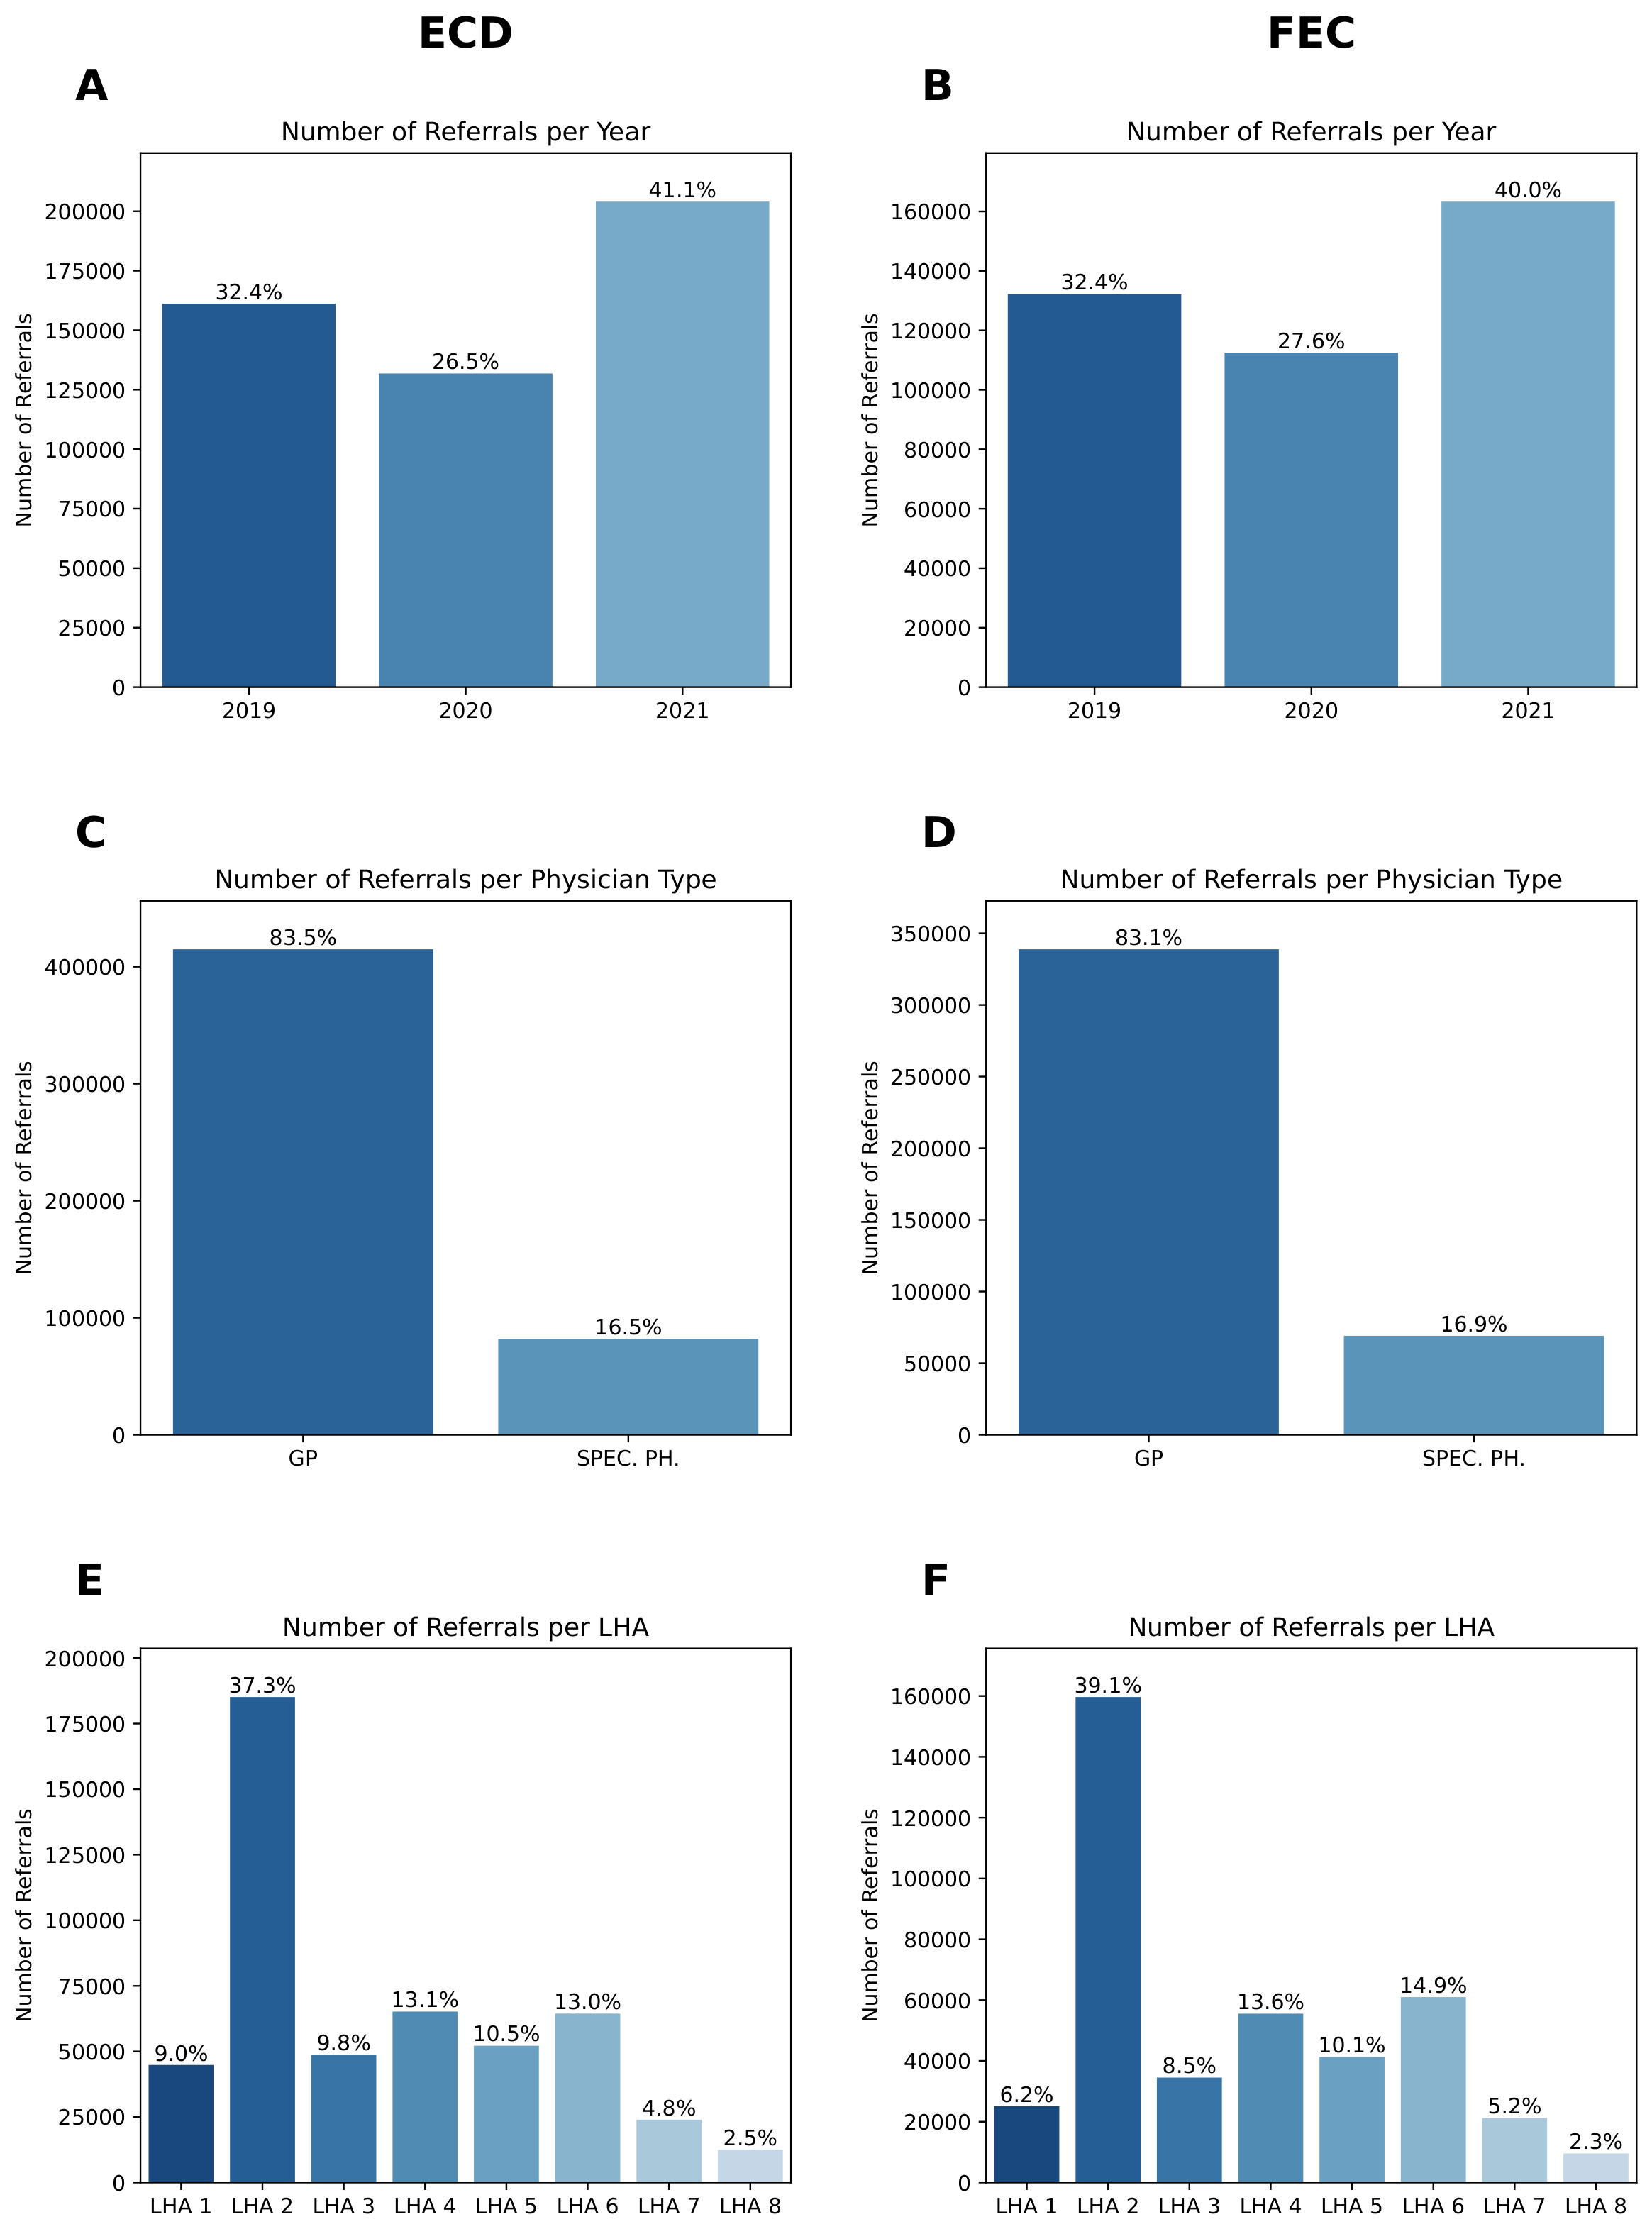

In [6]:
def plot_referral_distributions(dfs: dict, savepath: str = None):
    """Referral counts by year, physician type and LHA, side by side for every dataset in
    `dfs` (reproduces Supplementary Figure A.1)."""
    n_cols = len(dfs)
    fig, axs = plt.subplots(3, n_cols, figsize=(6.3 * n_cols, 17.2), gridspec_kw={"wspace": 0.3, "hspace": 0.4})
    if n_cols == 1:
        axs = axs.reshape(3, 1)

    groupings = [("ANNO", "Number of Referrals per Year"), ("PHYSICIAN_TYPE", "Number of Referrals per Physician Type"), ("LHA", "Number of Referrals per LHA")]

    for col, (name, df) in enumerate(dfs.items()):
        for row, (group_col, title) in enumerate(groupings):
            ax = axs[row, col]
            counts = df.groupby(group_col)["NUMERO"].sum()
            palette = list(reversed(sns.color_palette("Blues", n_colors=counts.shape[0] + 2)))[:-2]
            sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=palette)
            ax.set_title(title if col == 0 else "")
            ax.set_xlabel("")
            ax.set_ylabel("Number of Referrals")
            ax.set_ylim(0, counts.max() * 1.15)
            for i, value in enumerate(counts.values):
                ax.text(i, value, f"{value / counts.sum() * 100:.1f}%", ha="center", va="bottom", fontsize=10)
            ax.text(-0.1, 1.1, string.ascii_uppercase[row * n_cols + col], transform=ax.transAxes, size=20, weight="bold")
        axs[0, col].annotate(name, xy=(0.5, 1.25), xycoords="axes fraction", ha="center", fontsize=20, fontweight="bold")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


plot_referral_distributions({"ECD": df_ecd, "FEC": df_fec});

## 3. Pre-processing (§2.2.1, Supplementary Sec. C)

Clinical questions are lowercased, stripped of punctuation, and passed through two
corpus-driven corrections before clustering:

- **Abbreviation expansion**: words of length ≤ 3 are matched against a manually curated
  medical vocabulary (Supplementary Table C.1) and expanded to their full form.
- **Typo correction**: words occurring with frequency < 1% are replaced by the most similar
  word (edit distance ≥ 0.8, via `difflib.SequenceMatcher`) occurring with frequency > 1%
  (Supplementary Table C.2). The 0.8 similarity threshold was chosen by minimising errors on a
  manually reviewed sample of 100 corrections.

In [7]:
ITALIAN_STOPWORDS = set(stopwords.words("italian")) - {"nei"}
PUNCTUATION = set(string.punctuation)


def clean_clinical_question(text: str, replacements: dict) -> str:
    """Lowercase, strip punctuation/digits, expand abbreviations and drop stopwords."""
    if not isinstance(text, str):
        return ""
    no_punctuation = " ".join("".join(ch if ch not in PUNCTUATION else " " for ch in text).split())
    for pattern, replacement in replacements.items():
        no_punctuation = re.sub(pattern, replacement, no_punctuation, flags=re.IGNORECASE)
    lowered = no_punctuation.lower()
    no_stopwords = " ".join(w for w in lowered.split() if w not in ITALIAN_STOPWORDS)
    return re.sub(r"\d+\.?\d*\s*", "", no_stopwords)

### Abbreviation candidates (Supplementary Table C.1)

In [8]:
def word_frequencies(texts: pd.Series) -> pd.DataFrame:
    counts = collections.Counter(w for text in texts.dropna() for w in text.split())
    return pd.DataFrame(counts.most_common(), columns=["word", "frequency"])


def abbreviation_candidates(word_freq: pd.DataFrame, max_len: int = 3) -> pd.DataFrame:
    """Short, non-stopword tokens worth reviewing for abbreviation expansion."""
    has_number_or_punct = word_freq["word"].str.contains(r"[0-9!\"#$%&'()*+,\-./:;<=>?@\[\]^_`{|}~]")
    is_stopword = word_freq["word"].str.lower().isin(ITALIAN_STOPWORDS)
    candidates = word_freq[(word_freq["word"].str.len() <= max_len) & ~has_number_or_punct & ~is_stopword]
    return candidates.sort_values("frequency", ascending=False)


word_freq_ecd = word_frequencies(df_ecd["QUESITO_DIAGNOSTICO"])
abbreviation_candidates(word_freq_ecd).head(50)

,word,frequency
0,dx,41942
1,sx,35400
2,tvp,35392
3,inf,26644
4,sin,8490
5,pz,6100
6,ndd,4555
7,aa,4079
8,tvs,3650
9,sn,3055


In [9]:
def load_abbreviation_map(exam: str) -> dict:
    """Load the manually curated abbreviation -> expansion mapping (regex pattern -> replacement)
    for `exam` from `RESOURCES['abbreviations_<exam>']`, reviewed from the candidates above
    against a predefined medical vocabulary."""
    table = pd.read_csv(require_resource(f"abbreviations_{exam.lower()}"))
    return dict(zip(table["abbreviation"], table["expansion"]))


abbreviation_map = load_abbreviation_map("ECD")

### Typo correction (Supplementary Table C.2)

In [10]:
def find_typo_correction(word: str, word_freq: pd.DataFrame, min_frequency: int, min_similarity: float = 0.8):
    """Best correction for a low-frequency `word`: the highest-frequency word above
    `min_frequency` with similarity >= `min_similarity`, or None if no candidate qualifies."""
    candidates = word_freq[(word_freq["word"] != word) & (word_freq["frequency"] > min_frequency)].copy()
    candidates["similarity"] = candidates["word"].apply(lambda w: SequenceMatcher(None, w, word).ratio())
    candidates = candidates[candidates["similarity"] >= min_similarity].sort_values("similarity", ascending=False)
    return candidates.iloc[0]["word"] if len(candidates) else None


def build_typo_corrections(word_freq: pd.DataFrame, n_referrals: int, min_similarity: float = 0.8) -> pd.DataFrame:
    min_frequency = int(n_referrals * 0.01)
    rare_words = word_freq[word_freq["frequency"] <= min_frequency].copy()
    rare_words["correction"] = rare_words["word"].progress_apply(
        lambda w: find_typo_correction(w, word_freq, min_frequency, min_similarity)
    )
    return rare_words[rare_words["correction"].notna()]


typo_corrections_ecd = build_typo_corrections(word_freq_ecd, n_referrals=len(df_ecd))
typo_corrections_ecd.sort_values("frequency").head(50)

,word,frequency,correction
0,iprtensioone,1,ipertensione
1,stwnosi,1,stenosi
2,areomasica,1,ateromasia
3,aduta,1,caduta
4,clacifiche,1,calcifiche
5,lipitimiche,1,lipotimie
6,esignificative,1,significative
7,veriginosa,1,vertiginosa
8,lipotimoco,1,lipotimici
9,emicrani,1,emicrania


In [11]:
def apply_corpus_corrections(df: pd.DataFrame, replacements: dict, typo_corrections: pd.DataFrame) -> None:
    """Populate `QUESITO_CLEAN` with the fully pre-processed clinical question."""
    df["QUESITO_CLEAN"] = df["QUESITO_DIAGNOSTICO"].progress_apply(lambda t: clean_clinical_question(t, replacements))
    correction_map = dict(zip(typo_corrections["word"], typo_corrections["correction"]))
    df["QUESITO_CLEAN"] = df["QUESITO_CLEAN"].apply(
        lambda text: " ".join(correction_map.get(tok, tok) for tok in text.split())
    )


apply_corpus_corrections(df_ecd, abbreviation_map, typo_corrections_ecd)
df_ecd[["QUESITO_DIAGNOSTICO", "QUESITO_CLEAN"]].head()

The same steps are repeated for FEC, with its own abbreviation table and typo corrections:

In [12]:
word_freq_fec = word_frequencies(df_fec["QUESITO_DIAGNOSTICO"])
abbreviation_map_fec = load_abbreviation_map("FEC")
typo_corrections_fec = build_typo_corrections(word_freq_fec, n_referrals=len(df_fec))
apply_corpus_corrections(df_fec, abbreviation_map_fec, typo_corrections_fec)

## 4. Manual annotations and guidelines (§2.1.2-2.1.3, Supplementary Sec. B)

For each exam, 1,000 randomly sampled distinct clinical questions were manually labelled with
the primary disease/symptom motivating the referral (n = 2,487 referrals for ECD, n = 3,556 for
FEC), consulting a board-certified angiologist and gastroenterologist to resolve ambiguous
cases. Labels not covered by the regional guidelines were created ad hoc; `'other'` is reserved
for referrals with no identifiable symptom or disease. See Supplementary Tables B.1-B.2 for the
full label inventory.

In [13]:
def load_manual_annotations(exam: str) -> pd.DataFrame:
    """Load the 1,000 manually annotated clinical questions for `exam` from
    `RESOURCES['annotations_<exam>']`, with columns `QUESITO_DIAGNOSTICO`, `LABEL`
    (disease/symptom, Italian) and `NUMERO` (referral count)."""
    return pd.read_csv(require_resource(f"annotations_{exam.lower()}"))


def restrict_to_frequent_labels(labels: pd.Series, min_share: float = 0.01) -> pd.Series:
    """Merge disease labels occurring in less than `min_share` of the annotated CQs into
    'other', matching the paper's evaluation procedure (§2.3.2)."""
    frequent = labels.value_counts(normalize=True)
    frequent = frequent[frequent > min_share].index
    return labels.where(labels.isin(frequent), "other")


annotations_ecd = load_manual_annotations("ECD")
annotations_ecd["LABEL"] = restrict_to_frequent_labels(annotations_ecd["LABEL"])

annotations_fec = load_manual_annotations("FEC")
annotations_fec["LABEL"] = restrict_to_frequent_labels(annotations_fec["LABEL"])

### Appropriateness guideline mapping (Supplementary Fig. B.1, Table 4)

The Lombardy Region resolutions ([DGR X/3993](https://www.regione.lombardia.it/wps/wcm/connect/f51334d7-fb9e-4151-ac34-b2e5dc41ff36/dgr_3993_04_08_15.pdf),
[DGR X/4702](https://www.regione.lombardia.it/wps/wcm/connect/f873eec5-1cf4-4446-8d33-dab9c0fea7ff/DGR2015_4702_regole2016.pdf))
define, for each exam, which referral motivations are appropriate, inappropriate, or
appropriate only conditional on clinical qualifiers often missing from the free text (*likely*
appropriate/inappropriate). Motivations outside these lists are `undetermined`. The mapping
below reproduces the disease-label -> guideline-category assignment reported in Table 4.

In [14]:
ECD_GUIDELINE_CATEGORY = {
    "thrombosis": "appropriate",
    "(thrombo)phlebitis": "appropriate",
    "saphenectomy": "appropriate",
    "varices surgery": "appropriate",
    "ulcer": "appropriate",
    "surgery": "appropriate",
    "venous insufficiency": "inappropriate",
    "edema": "inappropriate",
    "paresthesias": "inappropriate",
    "varices": "likely",
}

FEC_GUIDELINE_CATEGORY = {
    "polyps": "appropriate",
    "occult blood": "appropriate",
    "colon cancer": "appropriate",
    "anaemia": "appropriate",
    "chronic diarrhoea": "appropriate",
    "suspected colic lesion detected by other investigation technique": "appropriate",
    "colon cancer familiarity / prevention": "likely",
    "chronic inflammatory bowel disease": "likely",
    "diverticulosis": "inappropriate",
    "diverticulitis": "inappropriate",
    "irritable bowel syndrome": "inappropriate",
}


def get_appropriateness_category(disease_label: str, exam: str) -> str:
    """Four-class appropriateness scheme (§2.3.2): appropriate / inappropriate / likely
    (in)appropriate / undetermined (motivation not addressed by the guidelines)."""
    guideline = ECD_GUIDELINE_CATEGORY if exam == "ECD" else FEC_GUIDELINE_CATEGORY
    return guideline.get(str(disease_label).lower(), "undetermined")

## 5. Text embedding (§2.2.2)

Clinical questions are embedded with **UmBERTo-E3C**, an Italian BERT variant (UmBERTo,
commoncrawl-cased) fine-tuned on the E3C corpus of Italian case reports, as validated for
Italian discharge letters in Torri et al., *Scientific Reports* (2026). Contextual embeddings
consistently outperform vocabulary-based (TF-IDF) and static (Word2Vec) representations for
this kind of noisy clinical text (see the comparative evaluation in Section 8).

In [15]:
UMBERTO_BASE_CHECKPOINT = "Musixmatch/umberto-commoncrawl-cased-v1"


def load_umberto(variant: str):
    """Load the tokenizer and encoder for `variant` in {'umberto-base', 'umberto-e3c'}, on
    GPU if available and CPU otherwise.

    'umberto-base' is the off-the-shelf checkpoint (used as a baseline in Table 5).
    'umberto-e3c' is the E3C-finetuned checkpoint used by the main pipeline, loaded from
    `RESOURCES['umberto_e3c_checkpoint']`.
    """
    tokenizer = AutoTokenizer.from_pretrained(UMBERTO_BASE_CHECKPOINT)
    if variant == "umberto-base":
        model = AutoModel.from_pretrained(UMBERTO_BASE_CHECKPOINT)
    elif variant == "umberto-e3c":
        model = AutoModel.from_pretrained(require_resource("umberto_e3c_checkpoint"))
    else:
        raise ValueError(f"Unrecognised UmBERTo variant: {variant}")
    return model.to(DEVICE).eval(), tokenizer


def embed_texts(texts: list, model, tokenizer, batch_size: int = 32) -> np.ndarray:
    """Mask-aware mean-pooled last-hidden-state embedding for each text in `texts`, batched for
    throughput on CPU-only machines (the paper's own environment had none)."""
    embeddings = []
    with torch.no_grad():
        for start in tqdm(range(0, len(texts), batch_size)):
            batch = texts[start:start + batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(DEVICE)
            hidden_states = model(**encoded).last_hidden_state
            mask = encoded["attention_mask"].unsqueeze(-1)
            pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            embeddings.append(pooled.cpu().numpy())
    return np.vstack(embeddings)

In [16]:
umberto_e3c, umberto_e3c_tokenizer = load_umberto("umberto-e3c")

## 6. Clustering, summarisation and guideline mapping (§2.2.3-2.2.4)

Clinical questions are clustered on their (PCA-reduced) UmBERTo-E3C embeddings with
**HDBSCAN**, run **iteratively**: `min_cluster_size` starts at 500 and is halved at each
round down to 10, re-clustering only the points left unassigned by the previous round
(`min_samples=5`, `cluster_selection_epsilon=0.1`), so that both large, common motivations and
small, rare ones are captured. Each cluster is then:

1. **Summarised** by its most frequent, most discriminative keywords (decreasing frequency
   threshold from 80% until at least two keywords are found; keywords occurring in more than
   half of all clusters are treated as generic stop words and discarded).
2. **Mapped to a guideline entry** by cosine similarity between the cluster's keyword
   embedding and each guideline item's embedding, if the best match exceeds 0.50 — otherwise the
   cluster is left unmapped (a referral motivation not covered by current guidelines).

Because of the size of the datasets and the constraints of the secure, offline, 16GB-RAM
environment where they were processed, clustering is run in **chunks of 30,000 distinct
clinical questions**.

In [17]:
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances


def reduce_dimensionality(embeddings: np.ndarray, variance_threshold: float = 0.8) -> np.ndarray:
    return PCA(n_components=variance_threshold, random_state=RANDOM_STATE).fit_transform(embeddings)


def recursive_hdbscan(embeddings: np.ndarray, min_cluster_size_start: int = 500, min_cluster_size_stop: int = 10, min_samples: int = 5, cluster_selection_epsilon: float = 0.1) -> np.ndarray:
    """Iterative HDBSCAN: `min_cluster_size` is halved at each round, re-clustering only the
    points left unassigned (-1) by the previous round."""
    labels = np.full(len(embeddings), -1)
    unclustered = np.arange(len(embeddings))
    min_cluster_size = min_cluster_size_start
    next_cluster_id = 0

    while min_cluster_size >= min_cluster_size_stop and len(unclustered):
        distances = pairwise_distances(embeddings[unclustered], metric="cosine")
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            cluster_selection_epsilon=cluster_selection_epsilon,
            metric="precomputed",
        )
        round_labels = clusterer.fit_predict(distances.astype("float64"))
        assigned = round_labels != -1
        labels[unclustered[assigned]] = round_labels[assigned] + next_cluster_id
        next_cluster_id += round_labels.max() + 1 if assigned.any() else 0
        unclustered = unclustered[~assigned]
        min_cluster_size //= 2

    return labels

In [18]:
def extract_cluster_keywords(texts: list, threshold: float = 0.8) -> list:
    """Highest-frequency, non-stopword tokens in `texts`, lowering `threshold` until at least
    two keywords are found (or it becomes negligible)."""
    tokens = [w.lower() for t in texts for w in re.split(r"[,;\s.]+", t) if w and w.lower() not in ITALIAN_STOPWORDS]
    if not tokens:
        return []
    frequencies = collections.Counter(tokens)
    total = len(tokens)
    relative_freq = {w: c / total for w, c in frequencies.items()}

    keywords = {}
    while len(keywords) < 2 and threshold > 1e-6:
        keywords = {w: f for w, f in relative_freq.items() if f > threshold}
        threshold /= 2
    return list(keywords) or [""]


def summarize_clusters(df: pd.DataFrame, cluster_col: str, text_col: str = "QUESITO_CLEAN") -> dict:
    """Per-cluster keywords (step 1), with keywords generic to more than half the clusters
    dropped as corpus-wide stop words (step 2)."""
    keywords_by_cluster = {
        cluster_id: extract_cluster_keywords(group[text_col].tolist())
        for cluster_id, group in df.groupby(cluster_col)
    }
    keyword_cluster_freq = collections.Counter(w for kws in keywords_by_cluster.values() for w in kws)
    generic = {w for w, n in keyword_cluster_freq.items() if n > len(keywords_by_cluster) / 2}
    return {cid: [w for w in kws if w not in generic] or kws for cid, kws in keywords_by_cluster.items()}

In [19]:
def load_guideline_items(exam: str) -> pd.DataFrame:
    """Load the guideline-derived clinical-question items for `exam` from
    `RESOURCES['guideline_items_<exam>']` (Supplementary Fig. B.1), as columns `label`
    (English category, e.g. 'thrombosis') and `description` (the Italian guideline wording,
    e.g. 'sospetta tvp arto inferiore')."""
    return pd.read_csv(require_resource(f"guideline_items_{exam.lower()}"))


# Selected by the sensitivity analysis in Section 8.5; §2.2.4 uses this default.
GUIDELINE_MATCH_THRESHOLD = 0.5


def cluster_guideline_similarities(cluster_keywords: dict, guideline_items: pd.DataFrame, model, tokenizer) -> tuple:
    """Cosine similarity between each cluster's keyword embedding and every guideline item's
    embedding. Split out from `map_clusters_to_guidelines` so a threshold sweep (Section 8.5)
    can reuse the same embeddings instead of recomputing them for every threshold tried."""
    cluster_ids = list(cluster_keywords)
    keyword_embeddings = embed_texts([" ".join(cluster_keywords[cid]) for cid in cluster_ids], model, tokenizer)
    guideline_embeddings = embed_texts(guideline_items["description"].tolist(), model, tokenizer)
    return cluster_ids, cosine_similarity(keyword_embeddings, guideline_embeddings)


def assign_by_threshold(similarities: np.ndarray, entity_ids: list, guideline_labels: np.ndarray, threshold: float) -> dict:
    """The nearest guideline label for each row of `similarities`, or None if its best
    similarity does not exceed `threshold`."""
    best = similarities.argmax(axis=1)
    best_score = similarities.max(axis=1)
    return {
        entity_id: (guideline_labels[best[i]] if best_score[i] > threshold else None)
        for i, entity_id in enumerate(entity_ids)
    }


def map_clusters_to_guidelines(cluster_keywords: dict, guideline_items: pd.DataFrame, model, tokenizer, threshold: float = GUIDELINE_MATCH_THRESHOLD) -> dict:
    """Assign each cluster to the guideline entry with the highest keyword-embedding cosine
    similarity, if it exceeds `threshold` (§2.2.4); unmapped clusters are motivations not
    covered by current guidelines."""
    cluster_ids, similarities = cluster_guideline_similarities(cluster_keywords, guideline_items, model, tokenizer)
    return assign_by_threshold(similarities, cluster_ids, guideline_items["label"].values, threshold)

### Running the full pipeline

`run_referral_pipeline` chains embedding, chunked recursive clustering, summarisation and
guideline mapping for one exam's full corpus of distinct clinical questions — this is the exact
procedure used both for the population-scale analysis (Section 10, run once on the whole
dataset) and for validating against the manually annotated subset (Section 9, where only the
annotated CQs are scored, but clustering still runs on the *entire* corpus so that cluster
composition reflects real-world usage, per §2.3.2).

In [20]:
def assign_disease_and_appropriateness(df: pd.DataFrame, cluster_col: str, exam: str, model, tokenizer, text_col: str = "QUESITO_CLEAN", guideline_threshold: float = GUIDELINE_MATCH_THRESHOLD) -> pd.DataFrame:
    """Shared post-clustering steps, reused by every clustering method compared in Section 8:
    summarise clusters, map them to a guideline entry, and derive the appropriateness class."""
    guideline_items = load_guideline_items(exam)
    df = df.copy()

    cluster_keywords = summarize_clusters(df, cluster_col, text_col)
    df["cluster_keywords"] = df[cluster_col].map(cluster_keywords)

    cluster_to_guideline = map_clusters_to_guidelines(cluster_keywords, guideline_items, model, tokenizer, threshold=guideline_threshold)
    df["disease_label"] = df[cluster_col].map(cluster_to_guideline).fillna("other")
    df["appropriateness"] = df["disease_label"].apply(lambda label: get_appropriateness_category(label, exam))
    return df


def run_referral_pipeline(df: pd.DataFrame, exam: str, model, tokenizer, chunk_size: int = 30_000, text_col: str = "QUESITO_CLEAN", guideline_threshold: float = GUIDELINE_MATCH_THRESHOLD) -> pd.DataFrame:
    """Cluster every distinct clinical question in `df` with the main iterative-HDBSCAN
    pipeline, chunked to fit memory, then run the shared post-clustering steps above. Returns
    one row per distinct `text_col` value with `cluster_id`, `cluster_keywords`, `disease_label`
    and `appropriateness`. Passing `text_col='QUESITO_DIAGNOSTICO'` reproduces the
    no-pre-processing ablation of Supplementary Table C.3."""
    unique_cq = df.drop_duplicates(text_col)[[text_col]].reset_index(drop=True)

    chunks = []
    next_cluster_id = 0
    for start in tqdm(range(0, len(unique_cq), chunk_size)):
        chunk = unique_cq.iloc[start:start + chunk_size].copy()
        embeddings = embed_texts(chunk[text_col].tolist(), model, tokenizer)
        reduced = reduce_dimensionality(embeddings)
        chunk["cluster_id"] = recursive_hdbscan(reduced) + next_cluster_id
        next_cluster_id = chunk["cluster_id"].max() + 1
        chunks.append(chunk)
    unique_cq = pd.concat(chunks, ignore_index=True)

    return assign_disease_and_appropriateness(unique_cq, "cluster_id", exam, model, tokenizer, text_col=text_col, guideline_threshold=guideline_threshold)


clustered_ecd = run_referral_pipeline(df_ecd, "ECD", umberto_e3c, umberto_e3c_tokenizer)

The pipeline was developed and its hyperparameters selected **exclusively on ECD**; FEC is used
only for external validation, so running it here uses the exact same code and parameters:

In [21]:
clustered_fec = run_referral_pipeline(df_fec, "FEC", umberto_e3c, umberto_e3c_tokenizer)

## 7. Evaluation methodology (§2.3.2)

Performance is assessed at two levels against the manually annotated subset:

- **Disease label evaluation**: predicted `disease_label` vs. the manual `LABEL`.
- **Appropriateness label evaluation**: predicted vs. manual `appropriateness` (the four-class
  scheme from Section 4).

For both, metrics are computed **per distinct clinical question (CQ)** and **weighted by
referral count (REF)**, with 95% bootstrapped confidence intervals.

In [22]:
def merge_predictions_with_annotations(df_raw: pd.DataFrame, predictions: pd.DataFrame, annotations: pd.DataFrame, exam: str, key_col: str = "QUESITO_CLEAN") -> pd.DataFrame:
    """Recover, for every annotated clinical question, its predicted cluster outcome and its
    referral count `NUMERO` in the full dataset (so REF-level metrics reflect real-world
    frequency, as in §2.3.2). `key_col` is the text column the predictions were clustered on
    (`QUESITO_CLEAN` normally, `QUESITO_DIAGNOSTICO` for the Table C.3 ablation)."""
    raw_cols = list(dict.fromkeys(["QUESITO_DIAGNOSTICO", key_col, "NUMERO"]))
    with_counts = df_raw[raw_cols].merge(
        predictions[[key_col, "disease_label", "appropriateness"]], on=key_col, how="left"
    )
    merged = with_counts.merge(annotations[["QUESITO_DIAGNOSTICO", "LABEL"]], on="QUESITO_DIAGNOSTICO", how="inner")
    merged["true_appropriateness"] = merged["LABEL"].apply(lambda label: get_appropriateness_category(label, exam))
    group_cols = list(dict.fromkeys([key_col, "QUESITO_DIAGNOSTICO", "LABEL", "disease_label", "true_appropriateness", "appropriateness"]))
    return merged.groupby(group_cols, as_index=False)["NUMERO"].sum()

In [23]:
def classification_metrics(y_true, y_pred, sample_weight=None) -> dict:
    return classification_report(y_true, y_pred, sample_weight=sample_weight, output_dict=True, zero_division=0)


def summarize_evaluation(evaluation: pd.DataFrame) -> dict:
    """The four Table 5 metrics for an already-`merge_predictions_with_annotations`-ed
    evaluation frame: macro F1 for disease label and appropriateness, each at CQ level
    (unweighted) and REF level (weighted by `NUMERO`)."""
    return {
        "disease_f1_cq": classification_metrics(evaluation["LABEL"], evaluation["disease_label"])["macro avg"]["f1-score"],
        "disease_f1_ref": classification_metrics(evaluation["LABEL"], evaluation["disease_label"], evaluation["NUMERO"])["macro avg"]["f1-score"],
        "appropriateness_f1_cq": classification_metrics(evaluation["true_appropriateness"], evaluation["appropriateness"])["macro avg"]["f1-score"],
        "appropriateness_f1_ref": classification_metrics(evaluation["true_appropriateness"], evaluation["appropriateness"], evaluation["NUMERO"])["macro avg"]["f1-score"],
    }

In [24]:
def bootstrapped_classification_report(y_true, y_pred, sample_weight=None, n_iterations: int = 1000) -> pd.DataFrame:
    """Point estimate + 95% bootstrapped CI for precision/recall/F1 of every class, plus the
    macro/weighted averages (used to build Tables 1, 2 and 5)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    weights = np.array(sample_weight) if sample_weight is not None else None

    point = classification_metrics(y_true, y_pred, weights)
    boot = {key: {"precision": [], "recall": [], "f1-score": []} for key in point if key != "accuracy"}

    for _ in tqdm(range(n_iterations)):
        idx = np.random.randint(0, len(y_true), len(y_true))
        w = weights[idx] if weights is not None else None
        rep = classification_metrics(y_true[idx], y_pred[idx], w)
        for key in boot:
            if key in rep:
                for metric in ("precision", "recall", "f1-score"):
                    boot[key][metric].append(rep[key][metric])

    rows = []
    for key, metrics in boot.items():
        row = {"class": key}
        for metric in ("precision", "recall", "f1-score"):
            point_value = point[key][metric] * 100
            lower, upper = np.percentile(boot[key][metric], [2.5, 97.5]) * 100
            row[metric] = f"{point_value:.2f} [{lower:.2f}-{upper:.2f}]"
        row["support"] = point[key].get("support")
        rows.append(row)
    return pd.DataFrame(rows)

### Confusion matrices (Figure 3)

In [25]:
def plot_confusion_matrices(merged_pairs: list, savepath: str = None):
    """`merged_pairs` is a list of (title, y_true, y_pred, labels, sample_weight_or_None) to
    plot as a grid of heatmaps, reproducing Figure 3's layout (CQ- and REF-level, per exam)."""
    n = len(merged_pairs)
    n_cols = 2
    n_rows = -(-n // n_cols)
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(7.5 * n_cols, 7.5 * n_rows), gridspec_kw={"hspace": 0.5, "wspace": 0.5})
    axs = np.array(axs).flatten()

    for ax, (title, y_true, y_pred, labels, weight) in zip(axs, merged_pairs):
        cm = confusion_matrix(y_true, y_pred, labels=labels, sample_weight=weight)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False, ax=ax, annot_kws={"size": 9})
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("Predicted Labels")
        ax.set_ylabel("True Labels")
        ax.set_title(title)

    for ax in axs[n:]:
        ax.axis("off")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight", dpi=300)
    return fig

## 8. Hyperparameter selection and comparative baselines (§2.3.3, Supplementary Sec. D)

Clustering algorithm and hyperparameters are selected **exclusively on ECD**; FEC is only used
for external validation (Section 9). All comparisons below score the *disease label*
evaluation (macro F1-CQ) on the manually annotated ECD subset.

### 8.1 HDBSCAN hyperparameter grid search (Supplementary Table D.4)

In [26]:
def score_clustering(unique_cq: pd.DataFrame, cluster_labels: np.ndarray, exam: str, model, tokenizer, df_raw: pd.DataFrame, annotations: pd.DataFrame) -> tuple:
    """Cluster -> summarise -> map to guidelines -> merge with annotations -> macro P/R/F1-CQ."""
    predictions = unique_cq.assign(cluster_id=cluster_labels)
    predictions = assign_disease_and_appropriateness(predictions, "cluster_id", exam, model, tokenizer)
    merged = merge_predictions_with_annotations(df_raw, predictions, annotations, exam)
    report = classification_metrics(merged["LABEL"], merged["disease_label"])
    return report["macro avg"]["precision"], report["macro avg"]["recall"], report["macro avg"]["f1-score"]

In [27]:
dev_cq = df_ecd.drop_duplicates("QUESITO_CLEAN")[["QUESITO_CLEAN"]].reset_index(drop=True)
dev_embeddings = embed_texts(dev_cq["QUESITO_CLEAN"].tolist(), umberto_e3c, umberto_e3c_tokenizer)
dev_embeddings_reduced = reduce_dimensionality(dev_embeddings)

In [28]:
from itertools import product

hdbscan_param_grid = {
    "min_cluster_size_start": [20, 50, 100, 200, 500],
    "min_samples": [1, 5, 10, 20],
    "cluster_selection_epsilon": [0.0, 0.1, 0.5],
}

grid_search_results = []
for min_cluster_size_start, min_samples, epsilon in tqdm(list(product(*hdbscan_param_grid.values()))):
    labels = recursive_hdbscan(
        dev_embeddings_reduced,
        min_cluster_size_start=min_cluster_size_start,
        min_cluster_size_stop=20,
        min_samples=min_samples,
        cluster_selection_epsilon=epsilon,
    )
    precision, recall, f1 = score_clustering(dev_cq, labels, "ECD", umberto_e3c, umberto_e3c_tokenizer, df_ecd, annotations_ecd)
    grid_search_results.append({
        "min_cluster_size": min_cluster_size_start, "min_samples": min_samples,
        "cluster_selection_epsilon": epsilon, "precision": precision, "recall": recall, "f1": f1,
    })

pd.DataFrame(grid_search_results).sort_values("f1", ascending=False)

### 8.2 K-Means, varying the number of clusters (Supplementary Fig. D.1)

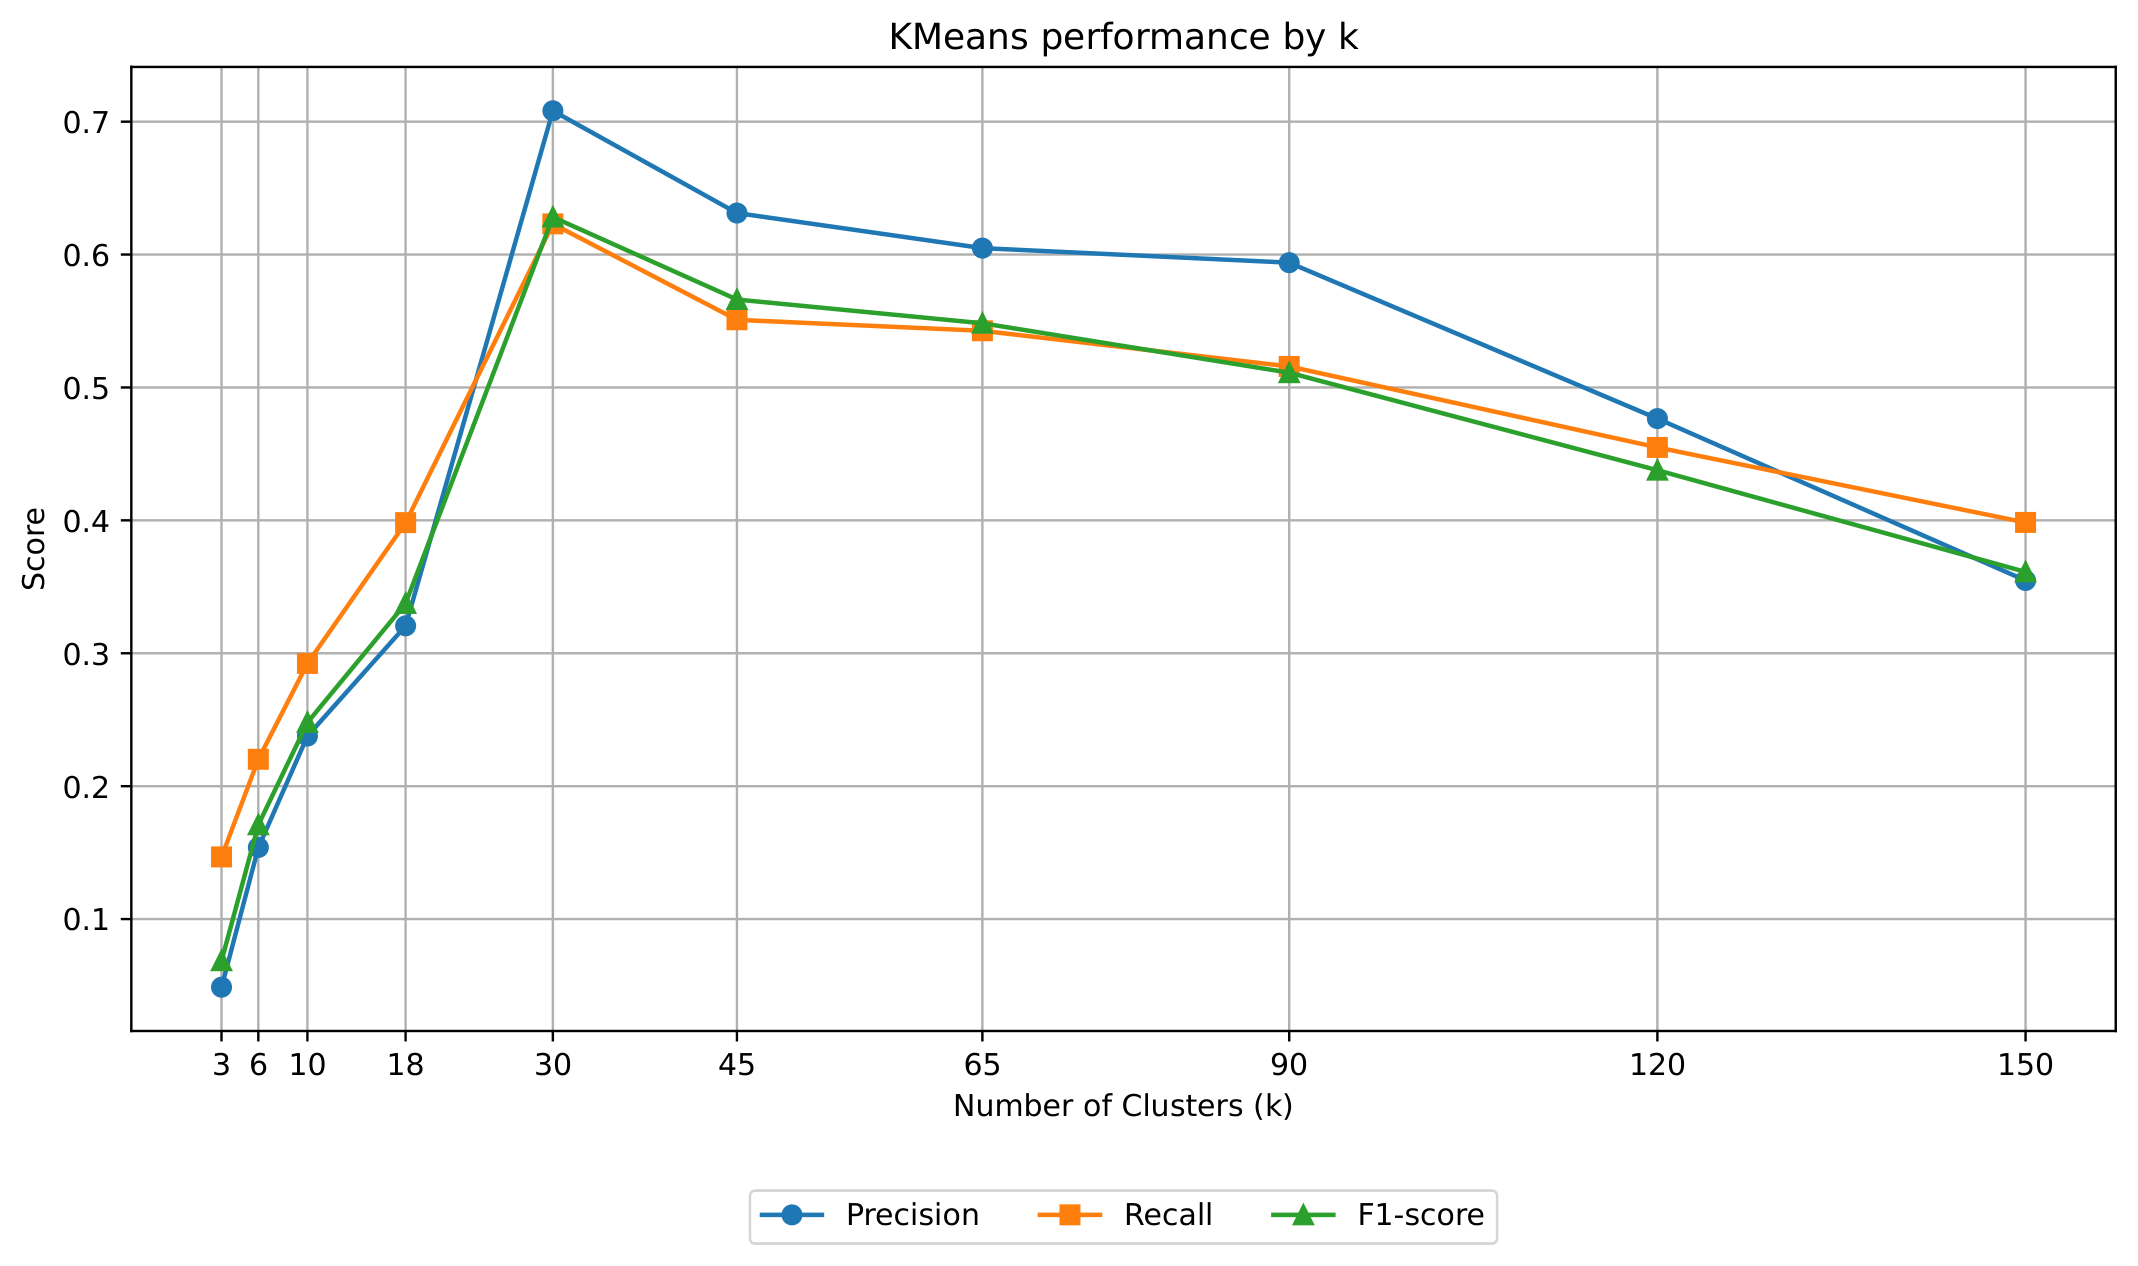

In [29]:
from sklearn.cluster import AgglomerativeClustering, KMeans


def sweep_clustering_k(embeddings: np.ndarray, unique_cq: pd.DataFrame, exam: str, model, tokenizer, df_raw: pd.DataFrame, annotations: pd.DataFrame, k_values: list, method: str) -> pd.DataFrame:
    clusterer_cls = KMeans if method == "kmeans" else AgglomerativeClustering
    rows = []
    for k in tqdm(k_values):
        clusterer = clusterer_cls(n_clusters=k, random_state=RANDOM_STATE) if method == "kmeans" else clusterer_cls(n_clusters=k)
        labels = clusterer.fit_predict(embeddings)
        precision, recall, f1 = score_clustering(unique_cq, labels, exam, model, tokenizer, df_raw, annotations)
        rows.append({"k": k, "precision": precision, "recall": recall, "f1": f1})
    return pd.DataFrame(rows)


def plot_k_sweep(results: pd.DataFrame, title: str, savepath: str = None):
    fig, ax = plt.subplots(figsize=(10, 6))
    for metric, marker in zip(["precision", "recall", "f1"], ["o", "s", "^"]):
        ax.plot(results["k"], results[metric], marker=marker, label=metric.capitalize())
    ax.set_xlabel("Number of Clusters (k)")
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.set_xticks(results["k"])
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
    ax.grid(True)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight", dpi=300)
    return fig


k_values = [3, 6, 10, 18, 30, 45, 65, 90, 120, 150]
kmeans_sweep = sweep_clustering_k(dev_embeddings_reduced, dev_cq, "ECD", umberto_e3c, umberto_e3c_tokenizer, df_ecd, annotations_ecd, k_values, "kmeans")
plot_k_sweep(kmeans_sweep, "KMeans performance by k");

### 8.3 Agglomerative hierarchical clustering, varying the number of clusters (Supplementary Fig. D.2)

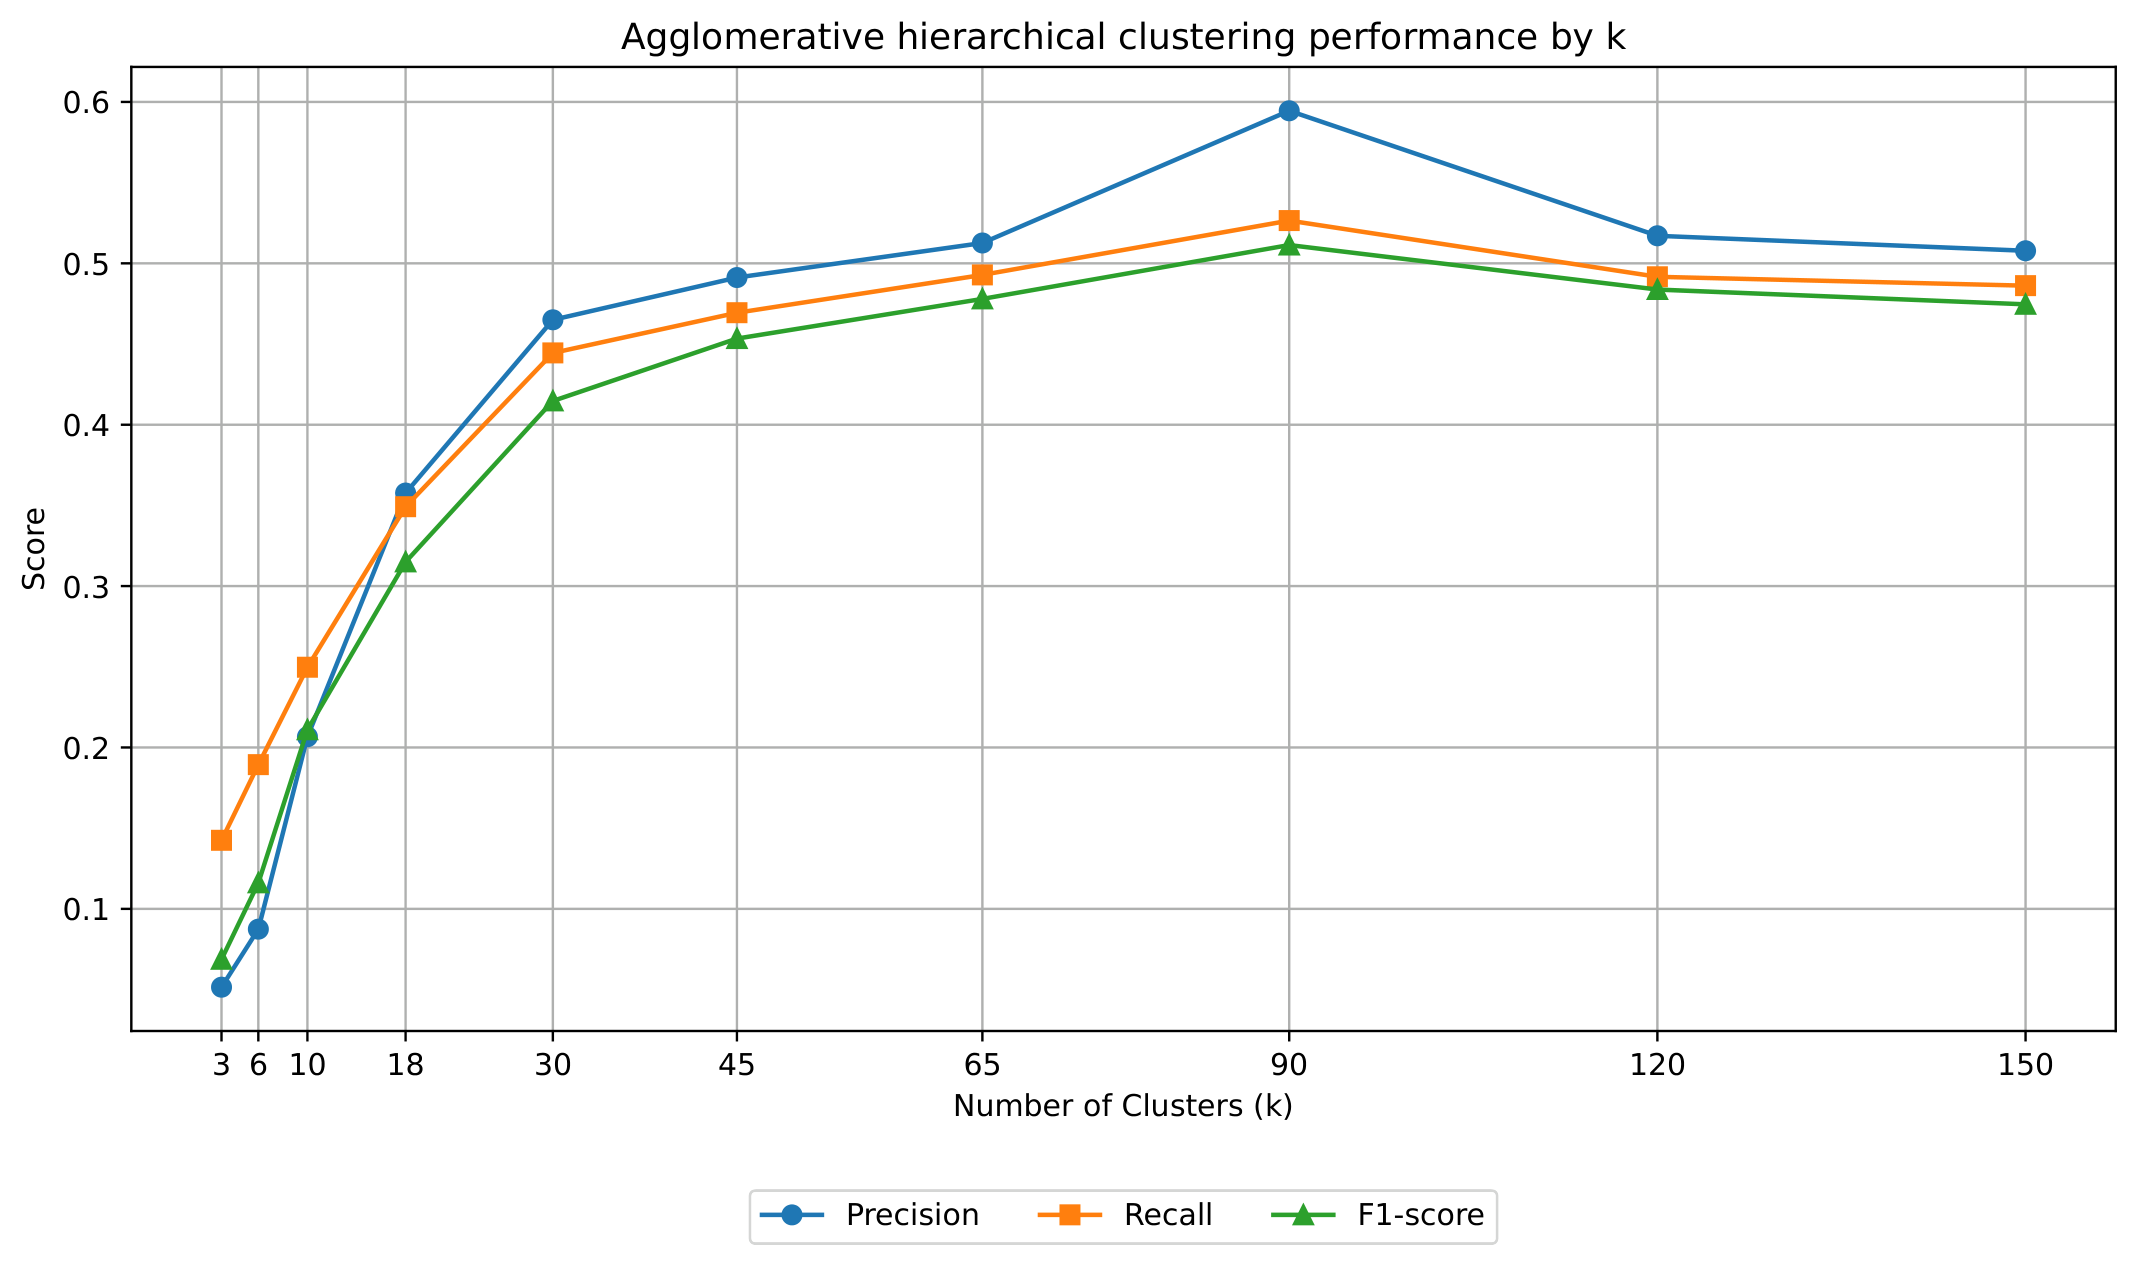

In [30]:
hierarchical_sweep = sweep_clustering_k(dev_embeddings_reduced, dev_cq, "ECD", umberto_e3c, umberto_e3c_tokenizer, df_ecd, annotations_ecd, k_values, "hierarchical")
plot_k_sweep(hierarchical_sweep, "Agglomerative hierarchical clustering performance by k");

### 8.4 Latent Dirichlet Allocation — number of topics via coherence

In [31]:
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer


def lda_coherence_sweep(texts: list, topic_range=range(2, 51)) -> pd.Series:
    vectorizer = CountVectorizer()
    document_term_matrix = vectorizer.fit_transform(texts)
    terms = vectorizer.get_feature_names_out()
    tokenized = [t.split() for t in texts]
    dictionary = Dictionary(tokenized)
    corpus = [dictionary.doc2bow(t) for t in tokenized]

    scores = {}
    for n_topics in tqdm(topic_range):
        lda = LatentDirichletAllocation(n_components=n_topics, random_state=RANDOM_STATE).fit(document_term_matrix)
        topics = [[terms[i] for i in comp.argsort()[-10:]] for comp in lda.components_]
        scores[n_topics] = CoherenceModel(topics=topics, texts=tokenized, corpus=corpus, dictionary=dictionary, coherence="c_v").get_coherence()
    return pd.Series(scores)


lda_coherence_ecd = lda_coherence_sweep(dev_cq["QUESITO_CLEAN"].fillna("").tolist())
LDA_K_ECD = int(lda_coherence_ecd.idxmax())
lda_coherence_ecd.plot(marker="o", title=f"Coherence Score vs. Number of Topics (ECD) — peak at k={LDA_K_ECD}", xlabel="Number of Topics", ylabel="Coherence Score");

In [32]:
fec_dev_cq = df_fec.drop_duplicates("QUESITO_CLEAN")[["QUESITO_CLEAN"]].reset_index(drop=True)
lda_coherence_fec = lda_coherence_sweep(fec_dev_cq["QUESITO_CLEAN"].fillna("").tolist())
LDA_K_FEC = int(lda_coherence_fec.idxmax())
lda_coherence_fec.plot(marker="o", title=f"Coherence Score vs. Number of Topics (FEC) — peak at k={LDA_K_FEC}", xlabel="Number of Topics", ylabel="Coherence Score");

The number of LDA topics used for each exam's baseline below is simply the coherence-maximising
`LDA_K_ECD`/`LDA_K_FEC` computed above, rather than a value fixed in advance.

### 8.5 Threshold selection for guideline mapping and direct embedding match

Both the guideline-mapping step (§2.2.4, cluster keyword vs. guideline item cosine similarity)
and the direct-embedding-match baseline (Section 8.6) discard a match below a similarity
threshold. Both thresholds are chosen the same way as every other hyperparameter above: by
sweeping candidate values on the ECD development set and picking the one that maximises
macro F1-CQ against the manual annotations. Embeddings/similarities are computed once and
reused across thresholds, since only the cut-off changes.

In [33]:
def sweep_threshold(thresholds: np.ndarray, predict_fn) -> pd.DataFrame:
    """`predict_fn(threshold)` returns a `disease_label` prediction frame for one threshold;
    this scores it against the ECD manual annotations for every threshold in `thresholds`."""
    rows = []
    for threshold in tqdm(thresholds):
        predictions = predict_fn(threshold)
        merged = merge_predictions_with_annotations(df_ecd, predictions, annotations_ecd, "ECD")
        f1 = classification_metrics(merged["LABEL"], merged["disease_label"])["macro avg"]["f1-score"]
        rows.append({"threshold": threshold, "f1": f1})
    return pd.DataFrame(rows)


def plot_threshold_sweep(results: pd.DataFrame, title: str, savepath: str = None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(results["threshold"], results["f1"], marker="o")
    best = results.loc[results["f1"].idxmax()]
    ax.axvline(best["threshold"], color="grey", linestyle="--", label=f"best = {best['threshold']:.2f}")
    ax.set_xlabel("Similarity threshold")
    ax.set_ylabel("Macro F1-CQ (disease label)")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight", dpi=300)
    return fig

**Guideline-mapping threshold** — clusters the ECD development set once with the selected HDBSCAN hyperparameters, then only the mapping threshold varies:

In [34]:
dev_cluster_labels = recursive_hdbscan(dev_embeddings_reduced)
dev_cluster_keywords = summarize_clusters(dev_cq.assign(cluster_id=dev_cluster_labels), "cluster_id")
dev_guideline_items = load_guideline_items("ECD")
dev_cluster_ids, dev_cluster_similarities = cluster_guideline_similarities(dev_cluster_keywords, dev_guideline_items, umberto_e3c, umberto_e3c_tokenizer)


def predict_with_guideline_threshold(threshold: float) -> pd.DataFrame:
    mapping = assign_by_threshold(dev_cluster_similarities, dev_cluster_ids, dev_guideline_items["label"].values, threshold)
    predictions = dev_cq.assign(cluster_id=dev_cluster_labels)
    predictions["disease_label"] = predictions["cluster_id"].map(mapping).fillna("other")
    return predictions


guideline_threshold_sweep = sweep_threshold(np.arange(0.30, 0.86, 0.05), predict_with_guideline_threshold)
GUIDELINE_MATCH_THRESHOLD = float(guideline_threshold_sweep.loc[guideline_threshold_sweep["f1"].idxmax(), "threshold"])
plot_threshold_sweep(guideline_threshold_sweep, "Guideline-mapping threshold selection", savepath="guideline_threshold_sweep.pdf");

**Direct-match threshold** — embeddings are computed once, then only the threshold varies:

In [35]:
DIRECT_MATCH_THRESHOLD = 0.6  # initial value; reassigned by the sweep below


def direct_match_similarities(unique_cq: pd.DataFrame, exam: str, model, tokenizer) -> tuple:
    """Embeddings + cosine similarities for the direct-match baseline, split out so the
    threshold sweep below can reuse them instead of recomputing embeddings for every threshold
    tried."""
    guideline_items = load_guideline_items(exam)
    cq_embeddings = embed_texts(unique_cq["QUESITO_CLEAN"].tolist(), model, tokenizer)
    guideline_embeddings = embed_texts(guideline_items["description"].tolist(), model, tokenizer)
    return guideline_items, cosine_similarity(cq_embeddings, guideline_embeddings)


def direct_match_predictions_from_similarities(unique_cq: pd.DataFrame, guideline_items: pd.DataFrame, similarities: np.ndarray, exam: str, threshold: float) -> pd.DataFrame:
    best_match = similarities.argmax(axis=1)
    best_score = similarities.max(axis=1)
    df = unique_cq.copy()
    df["disease_label"] = np.where(best_score > threshold, guideline_items["label"].values[best_match], "other")
    df["appropriateness"] = df["disease_label"].apply(lambda label: get_appropriateness_category(label, exam))
    return df


def direct_embedding_match(unique_cq: pd.DataFrame, exam: str, model, tokenizer, threshold: float = DIRECT_MATCH_THRESHOLD) -> pd.DataFrame:
    guideline_items, similarities = direct_match_similarities(unique_cq, exam, model, tokenizer)
    return direct_match_predictions_from_similarities(unique_cq, guideline_items, similarities, exam, threshold)


dev_direct_guideline_items, dev_direct_similarities = direct_match_similarities(dev_cq, "ECD", umberto_e3c, umberto_e3c_tokenizer)


def predict_with_direct_match_threshold(threshold: float) -> pd.DataFrame:
    return direct_match_predictions_from_similarities(dev_cq, dev_direct_guideline_items, dev_direct_similarities, "ECD", threshold)


direct_match_threshold_sweep = sweep_threshold(np.arange(0.30, 0.86, 0.05), predict_with_direct_match_threshold)
DIRECT_MATCH_THRESHOLD = float(direct_match_threshold_sweep.loc[direct_match_threshold_sweep["f1"].idxmax(), "threshold"])
plot_threshold_sweep(direct_match_threshold_sweep, "Direct embedding match threshold selection", savepath="direct_match_threshold_sweep.pdf");

`GUIDELINE_MATCH_THRESHOLD` and `DIRECT_MATCH_THRESHOLD` now hold the values selected by this
sweep, and are used by the baselines below and by `direct_embedding_match`. To propagate a
new `GUIDELINE_MATCH_THRESHOLD` to the main pipeline, re-run Section 6 passing it as
`guideline_threshold`.

### 8.6 Baseline representations and clustering methods for Table 5

Each alternative representation is clustered and scored exactly like the main pipeline, via
`assign_disease_and_appropriateness` and `merge_predictions_with_annotations` — only the
embedding/clustering step changes.

In [36]:
def evaluate_baseline(unique_cq: pd.DataFrame, cluster_labels: np.ndarray, exam: str, model, tokenizer, df_raw: pd.DataFrame, annotations: pd.DataFrame) -> dict:
    predictions = assign_disease_and_appropriateness(unique_cq.assign(cluster_id=cluster_labels), "cluster_id", exam, model, tokenizer)
    merged = merge_predictions_with_annotations(df_raw, predictions, annotations, exam)
    return summarize_evaluation(merged)


table5_rows = {}

**UmBERTo-Base** (off-the-shelf, not fine-tuned on clinical text):

In [37]:
umberto_base, umberto_base_tokenizer = load_umberto("umberto-base")
base_embeddings = embed_texts(dev_cq["QUESITO_CLEAN"].tolist(), umberto_base, umberto_base_tokenizer)
base_labels = recursive_hdbscan(reduce_dimensionality(base_embeddings))
table5_rows["UmBERTo-Base"] = evaluate_baseline(dev_cq, base_labels, "ECD", umberto_base, umberto_base_tokenizer, df_ecd, annotations_ecd)

**TF-IDF** (top 1,000 tokens, `TruncatedSVD` to 500 components, K-Means with k chosen by the elbow method — k=40 for ECD, k=35 for FEC):

In [38]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer


def elbow_k(X, k_range=range(2, 51)) -> int:
    inertias = [KMeans(n_clusters=k, random_state=RANDOM_STATE).fit(X).inertia_ for k in tqdm(k_range)]
    # second derivative peak = elbow
    return list(k_range)[int(np.argmax(np.diff(inertias, 2))) + 1]


tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(dev_cq["QUESITO_CLEAN"])
tfidf_reduced = TruncatedSVD(n_components=500, random_state=RANDOM_STATE).fit_transform(tfidf_matrix)

tfidf_k = elbow_k(tfidf_reduced)
tfidf_labels = KMeans(n_clusters=tfidf_k, random_state=RANDOM_STATE).fit_predict(tfidf_reduced)
table5_rows["TF-IDF"] = evaluate_baseline(dev_cq, tfidf_labels, "ECD", umberto_e3c, umberto_e3c_tokenizer, df_ecd, annotations_ecd)

**Word2Vec** (pre-trained Italian embeddings, mean-pooled, same K-Means procedure):

In [39]:
from gensim.models import KeyedVectors


def load_word2vec() -> KeyedVectors:
    return KeyedVectors.load(require_resource("word2vec_italian"))


def embed_word2vec(texts: list, model: KeyedVectors, dim: int = 300) -> np.ndarray:
    def sentence_vector(text):
        vectors = [model[w] for w in text.split() if w in model]
        return np.mean(vectors, axis=0) if vectors else np.zeros(dim)
    return np.vstack([sentence_vector(t) for t in texts])


word2vec_model = load_word2vec()
word2vec_embeddings = embed_word2vec(dev_cq["QUESITO_CLEAN"].tolist(), word2vec_model)
word2vec_k = elbow_k(word2vec_embeddings)
word2vec_labels = KMeans(n_clusters=word2vec_k, random_state=RANDOM_STATE).fit_predict(word2vec_embeddings)
table5_rows["Word2Vec"] = evaluate_baseline(dev_cq, word2vec_labels, "ECD", umberto_e3c, umberto_e3c_tokenizer, df_ecd, annotations_ecd)

**LDA** (`LDA_K_ECD` topics, chosen by coherence in Section 8.4):

In [40]:
lda_vectorizer = CountVectorizer()
lda_matrix = lda_vectorizer.fit_transform(dev_cq["QUESITO_CLEAN"].fillna(""))
lda_model = LatentDirichletAllocation(n_components=LDA_K_ECD, random_state=RANDOM_STATE).fit(lda_matrix)
lda_labels = lda_model.transform(lda_matrix).argmax(axis=1)
table5_rows["LDA"] = evaluate_baseline(dev_cq, lda_labels, "ECD", umberto_e3c, umberto_e3c_tokenizer, df_ecd, annotations_ecd)

**Direct Embedding Match** — no clustering step: each clinical question is matched directly to its nearest guideline item (cosine similarity, threshold selected in Section 8.5), skipping the cluster-then-map pipeline entirely:

In [41]:
direct_match_predictions = direct_embedding_match(dev_cq, "ECD", umberto_e3c, umberto_e3c_tokenizer, threshold=DIRECT_MATCH_THRESHOLD)
direct_match_merged = merge_predictions_with_annotations(df_ecd, direct_match_predictions, annotations_ecd, "ECD")
table5_rows["Embedding Match"] = summarize_evaluation(direct_match_merged)

pd.DataFrame(table5_rows).T  # preview on ECD only — Section 9.5 assembles the full Table 5 (ECD + FEC)

,disease_f1_cq,disease_f1_ref,appropriateness_f1_cq,appropriateness_f1_ref
Our Pipeline (UmBERTo-Base),77.21,81.89,83.13,86.55
Word2Vec,71.24,76.73,77.01,80.88
TF-IDF,42.43,45.45,67.92,74.22
LDA,28.48,29.90,47.83,41.31
Embedding Match,59.21,62.09,62.83,64.46


## 9. Results: validation against manual annotations (§3.1)

The main pipeline (`clustered_ecd`, `clustered_fec` from Section 6) is scored against the
manual annotations using the evaluation utilities from Section 7.

In [42]:
eval_ecd = merge_predictions_with_annotations(df_ecd, clustered_ecd, annotations_ecd, "ECD")
eval_fec = merge_predictions_with_annotations(df_fec, clustered_fec, annotations_fec, "FEC")

### 9.1 Disease label evaluation (Table 2)

In [43]:
def disease_label_report(evaluation: pd.DataFrame) -> pd.DataFrame:
    cq_report = bootstrapped_classification_report(evaluation["LABEL"], evaluation["disease_label"])
    ref_report = bootstrapped_classification_report(evaluation["LABEL"], evaluation["disease_label"], sample_weight=evaluation["NUMERO"])
    return cq_report.merge(ref_report, on="class", suffixes=("_CQ", "_REF"))


disease_report_ecd = disease_label_report(eval_ecd)
disease_report_ecd

,class,precision_CQ,recall_CQ,f1-score_CQ,support_CQ,precision_REF,recall_REF,f1-score_REF,support_REF
0,thrombosis,96.24,94.04,95.13,218,96.99,94.77,95.87,306
1,(thrombo)phlebitis,98.70,93.83,96.20,81,99.09,93.16,96.04,117
2,ulcer,95.83,92.00,93.88,25,97.44,92.68,95.00,41
3,saphenectomy,100.00,92.59,96.15,27,100.00,93.94,96.88,33
4,varices surgery,100.00,42.86,60.00,14,100.00,46.67,63.64,15
5,venous insufficiency,94.90,74.50,83.47,200,98.06,88.09,92.81,747
6,edema,85.47,96.15,90.50,104,89.51,97.32,93.25,149
7,paresthesias,100.00,81.25,89.66,16,100.00,88.00,93.62,25
8,varices,43.28,89.23,58.29,65,84.03,98.89,90.86,628
9,vasculopathy,82.14,44.23,57.50,52,95.33,68.92,80.00,148


In [44]:
disease_report_fec = disease_label_report(eval_fec)
disease_report_fec

,class,precision_CQ,recall_CQ,f1-score_CQ,support_CQ,precision_REF,recall_REF,f1-score_REF,support_REF
0,bleeding,100.00,77.91,87.59,163,100.00,97.31,98.64,1748
1,polyps,99.35,97.47,98.40,158,99.71,98.55,99.12,344
2,colon cancer,96.84,85.98,91.09,107,98.24,89.30,93.56,187
3,anaemia,92.75,98.46,95.52,65,95.73,97.39,96.55,115
4,chronic diarrhoea,100.00,82.14,90.20,28,100.00,93.46,96.62,107
5,colon cancer familiarity / prevention,97.56,86.33,91.60,139,98.57,91.39,94.85,302
6,chronic inflammatory bowel disease,100.00,89.29,94.34,56,100.00,88.37,93.83,86
7,diverticulosis,90.00,81.82,85.71,33,86.67,81.25,83.87,48
8,diverticulitis,100.00,92.86,96.30,14,100.00,89.29,94.34,28
9,abdominal pain,88.57,89.42,89.00,104,93.66,89.72,91.65,214


### 9.2 Appropriateness label evaluation (Table 1)

In [45]:
def appropriateness_report(evaluation: pd.DataFrame) -> pd.DataFrame:
    cq_report = bootstrapped_classification_report(evaluation["true_appropriateness"], evaluation["appropriateness"])
    ref_report = bootstrapped_classification_report(evaluation["true_appropriateness"], evaluation["appropriateness"], sample_weight=evaluation["NUMERO"])
    return cq_report.merge(ref_report, on="class", suffixes=("_CQ", "_REF"))


appropriateness_report_ecd = appropriateness_report(eval_ecd)
appropriateness_report_fec = appropriateness_report(eval_fec)
pd.concat({"ECD": appropriateness_report_ecd, "FEC": appropriateness_report_fec})

class          precision_CQ               recall_CQ  \
ECD 0    appropriate  98.55 [96.10-100.00]     93.15 [91.05-95.20]   
    1  inappropriate   91.29 [88.50-93.80]     81.88 [77.20-85.40]   
    2         likely   43.28 [38.10-48.50]     89.23 [84.10-94.20]   
    3   undetermined   84.62 [80.10-88.90]     79.20 [74.50-83.80]   
    4      macro avg   79.44 [76.50-82.10]     85.87 [83.20-88.50]   
    5   weighted avg   89.15 [87.50-91.00]     85.80 [83.90-87.50]   
FEC 0    appropriate  99.36 [98.48-100.00]     89.44 [86.79-91.86]   
    1  inappropriate  95.35 [88.00-100.00]     87.23 [76.60-96.08]   
    2         likely  98.27 [95.91-100.00]     87.18 [82.29-91.85]   
    3   undetermined   75.24 [70.26-79.94]  100.00 [100.00-100.00]   
    4      macro avg   92.05 [89.87-93.88]     90.96 [87.98-93.51]   
    5   weighted avg   93.24 [92.16-94.35]     91.40 [89.70-93.10]   

               f1-score_CQ  support_CQ         precision_REF  \
ECD 0  95.77 [94.12-97.45]         365  98.97 [97.50-100.00]   
    1  86.33 [82.50-89.90]         320   96.49 [95.10-97.80]   
    2  58.29 [53.20-63.10]          65   84.03 [81.50-86.50]   
    3  81.82 [77.50-86.10]         250   87.22 [84.50-89.80]   
    4  80.55 [78.10-83.20]        1000   91.68 [90.10-93.20]   
    5  86.83 [84.50-89.10]        1000   92.27 [91.10-93.50]   
FEC 0  94.14 [92.57-95.48]         521  99.88 [99.58-100.00]   
    1  91.11 [83.72-96.55]          47  95.71 [87.50-100.00]   
    2  92.39 [89.40-95.05]         195  98.88 [97.13-100.00]   
    3  85.87 [82.53-88.85]         237   84.19 [78.22-88.70]   
    4  90.88 [88.35-92.95]        1000   94.66 [92.18-96.46]   
    5  91.70 [90.12-93.26]        1000   97.07 [94.89-98.32]   

                   recall_REF         f1-score_REF  support_REF  
ECD 0     93.95 [92.10-95.60]  96.39 [95.10-97.60]          512  
    1     89.58 [87.50-91.50]  92.91 [91.00-94.80]          921  
    2     89.89 [87.50-92.10]  90.86 [89.10-92.60]          628  
    3     83.33 [80.10-86.50]  85.23 [83.00-87.50]          426  
    4     89.19 [87.50-91.00]  91.35 [89.80-92.80]         2487  
    5     89.49 [88.10-90.80]  91.79 [90.50-93.00]         2487  
FEC 0     96.96 [92.43-98.52]  98.40 [96.01-99.23]         2501  
    1     88.16 [77.02-96.93]  91.78 [83.58-97.41]           76  
    2     90.72 [84.79-95.08]  94.62 [91.34-97.07]          388  
    3  100.00 [100.00-100.00]  91.42 [87.78-94.01]          591  
    4     93.96 [90.54-96.47]  94.05 [91.49-95.87]         3556  
    5     96.60 [93.80-98.06]  96.68 [93.96-98.12]         3556

### 9.3 Confusion matrices (Figure 3)

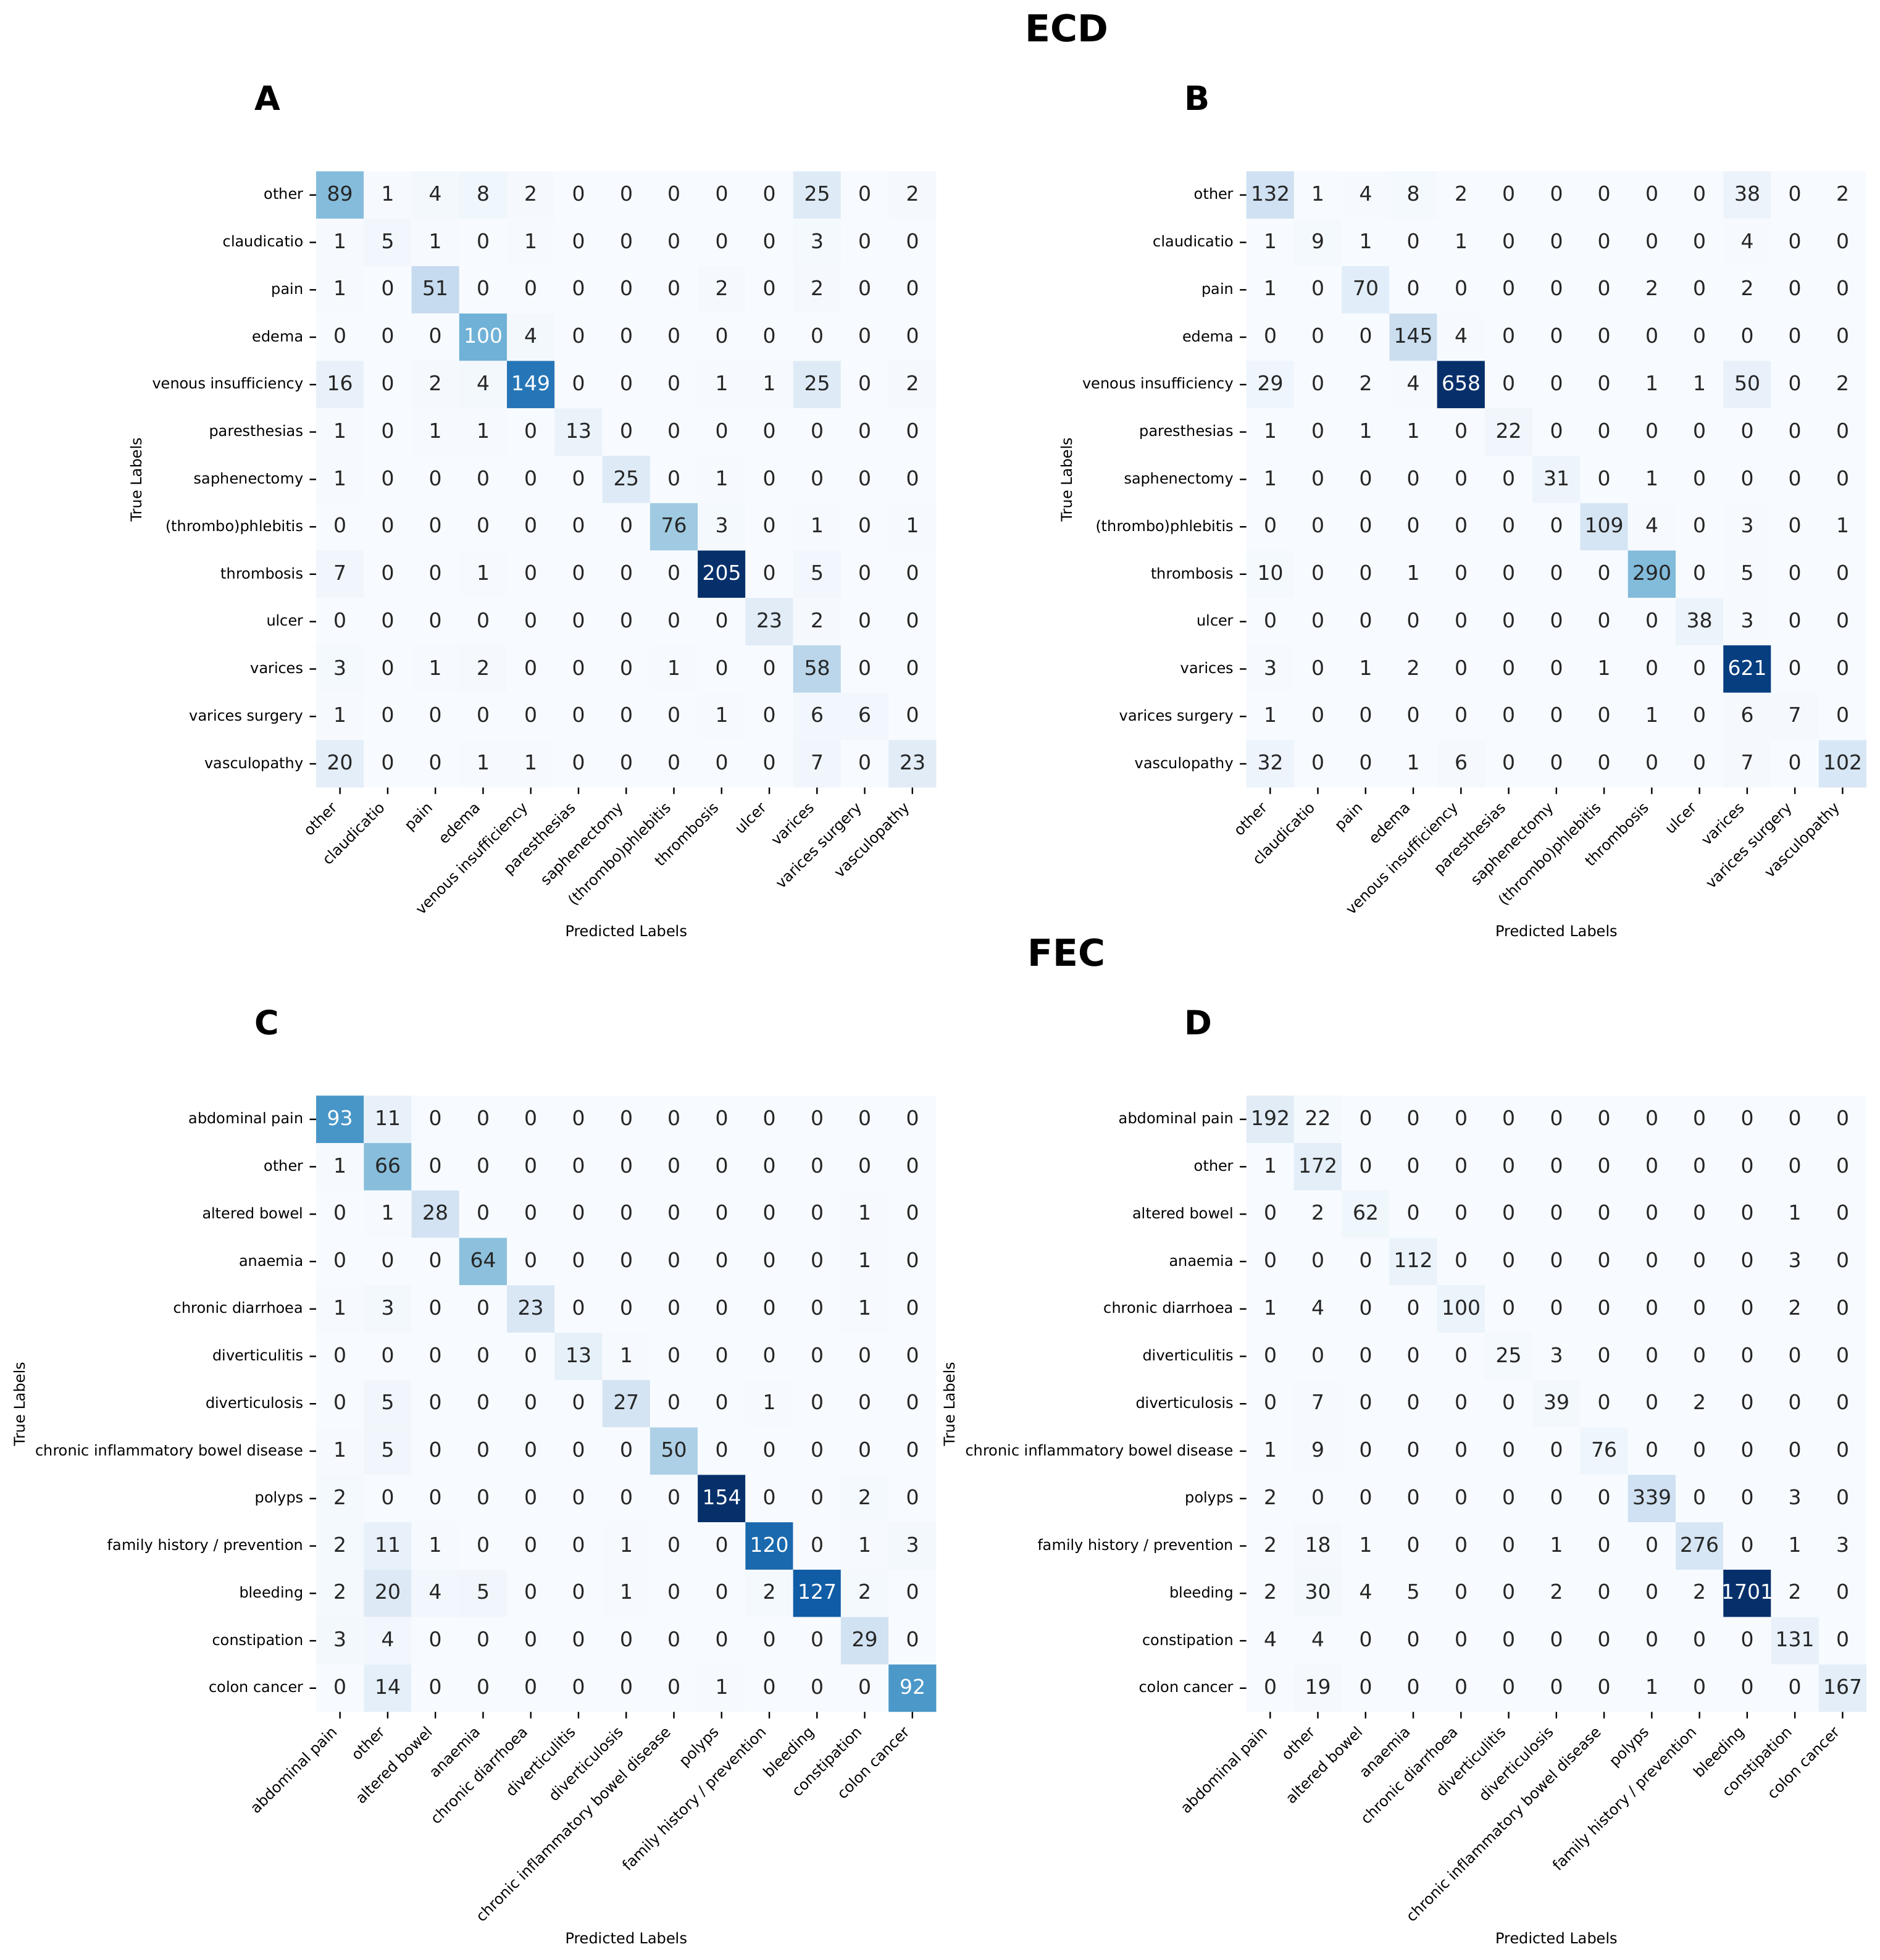

In [46]:
ecd_labels = sorted(eval_ecd["LABEL"].unique())
fec_labels = sorted(eval_fec["LABEL"].unique())

plot_confusion_matrices([
    ("ECD — by Clinical Question", eval_ecd["LABEL"], eval_ecd["disease_label"], ecd_labels, None),
    ("ECD — by Referral", eval_ecd["LABEL"], eval_ecd["disease_label"], ecd_labels, eval_ecd["NUMERO"]),
    ("FEC — by Clinical Question", eval_fec["LABEL"], eval_fec["disease_label"], fec_labels, None),
    ("FEC — by Referral", eval_fec["LABEL"], eval_fec["disease_label"], fec_labels, eval_fec["NUMERO"]),
], savepath="confusion_matrices_ecd_fec.pdf");

### 9.4 Effect of pre-processing (Supplementary Table C.3)

Re-running disease-label clustering directly on the raw `QUESITO_DIAGNOSTICO` (skipping
cleaning, abbreviation expansion and typo correction) quantifies the contribution of
Section 3's pre-processing step.

In [47]:
clustered_ecd_raw = run_referral_pipeline(df_ecd, "ECD", umberto_e3c, umberto_e3c_tokenizer, text_col="QUESITO_DIAGNOSTICO")
eval_ecd_raw = merge_predictions_with_annotations(df_ecd, clustered_ecd_raw, annotations_ecd, "ECD", key_col="QUESITO_DIAGNOSTICO")
disease_label_report(eval_ecd_raw)

### 9.5 Comparative evaluation (Table 5)

Section 8 walked through algorithm/hyperparameter selection on ECD step by step. `run_all_baselines`
packages that same sequence of alternative representations and clustering methods into one
function so it can be re-applied, unchanged, to FEC.

In [48]:
def run_all_baselines(unique_cq: pd.DataFrame, exam: str, df_raw: pd.DataFrame, annotations: pd.DataFrame, lda_k: int, main_pipeline_eval: pd.DataFrame) -> dict:
    rows = {"Our Pipeline (UmBERTo-E3C)": summarize_evaluation(main_pipeline_eval)}

    base_embeddings = embed_texts(unique_cq["QUESITO_CLEAN"].tolist(), umberto_base, umberto_base_tokenizer)
    base_labels = recursive_hdbscan(reduce_dimensionality(base_embeddings))
    rows["UmBERTo-Base"] = evaluate_baseline(unique_cq, base_labels, exam, umberto_base, umberto_base_tokenizer, df_raw, annotations)

    tfidf_matrix = TfidfVectorizer(max_features=1000).fit_transform(unique_cq["QUESITO_CLEAN"])
    tfidf_reduced = TruncatedSVD(n_components=500, random_state=RANDOM_STATE).fit_transform(tfidf_matrix)
    tfidf_labels = KMeans(n_clusters=elbow_k(tfidf_reduced), random_state=RANDOM_STATE).fit_predict(tfidf_reduced)
    rows["TF-IDF"] = evaluate_baseline(unique_cq, tfidf_labels, exam, umberto_e3c, umberto_e3c_tokenizer, df_raw, annotations)

    w2v_embeddings = embed_word2vec(unique_cq["QUESITO_CLEAN"].tolist(), word2vec_model)
    w2v_labels = KMeans(n_clusters=elbow_k(w2v_embeddings), random_state=RANDOM_STATE).fit_predict(w2v_embeddings)
    rows["Word2Vec"] = evaluate_baseline(unique_cq, w2v_labels, exam, umberto_e3c, umberto_e3c_tokenizer, df_raw, annotations)

    lda_matrix = CountVectorizer().fit_transform(unique_cq["QUESITO_CLEAN"].fillna(""))
    lda_labels = LatentDirichletAllocation(n_components=lda_k, random_state=RANDOM_STATE).fit_transform(lda_matrix).argmax(axis=1)
    rows["LDA"] = evaluate_baseline(unique_cq, lda_labels, exam, umberto_e3c, umberto_e3c_tokenizer, df_raw, annotations)

    match_predictions = direct_embedding_match(unique_cq, exam, umberto_e3c, umberto_e3c_tokenizer, threshold=DIRECT_MATCH_THRESHOLD)
    match_merged = merge_predictions_with_annotations(df_raw, match_predictions, annotations, exam)
    rows["Embedding Match"] = summarize_evaluation(match_merged)

    return rows


table5_ecd = pd.DataFrame(run_all_baselines(dev_cq, "ECD", df_ecd, annotations_ecd, lda_k=LDA_K_ECD, main_pipeline_eval=eval_ecd)).T
table5_fec = pd.DataFrame(run_all_baselines(fec_dev_cq, "FEC", df_fec, annotations_fec, lda_k=LDA_K_FEC, main_pipeline_eval=eval_fec)).T

pd.concat({"ECD": table5_ecd, "FEC": table5_fec})

disease_f1_cq  disease_f1_ref  \
ECD Our Pipeline (UmBERTo-E3C)           86.81           92.43   
    Our Pipeline (UmBERTo-Base)          77.21           81.89   
    Word2Vec                             71.24           76.73   
    TF-IDF                               42.43           45.45   
    LDA                                  28.48           29.90   
    Embedding Match                      59.21           62.09   
FEC Our Pipeline (UmBERTo-E3C)           88.60           92.67   
    Our Pipeline (UmBERTo-Base)          79.63           83.88   
    Word2Vec                             75.51           77.92   
    TF-IDF                               54.59           56.74   
    LDA                                  38.02           34.88   
    Embedding Match                      70.54           73.03   

                                 appropriateness_f1_cq  appropriateness_f1_ref  
ECD Our Pipeline (UmBERTo-E3C)                   89.24                   93.58  
    Our Pipeline (UmBERTo-Base)                  83.13                   86.55  
    Word2Vec                                     77.01                   80.88  
    TF-IDF                                       67.92                   74.22  
    LDA                                          47.83                   41.31  
    Embedding Match                              62.83                   64.46  
FEC Our Pipeline (UmBERTo-E3C)                   90.88                   94.05  
    Our Pipeline (UmBERTo-Base)                  83.84                   85.73  
    Word2Vec                                     78.43                   80.38  
    TF-IDF                                       62.20                   64.29  
    LDA                                          42.03                   38.81  
    Embedding Match                              74.20                   77.15

## 10. Population-scale analysis (§3.2, Table 4)

`clustered_ecd`/`clustered_fec` (Section 6) already hold a predicted `disease_label` and
`appropriateness` for every distinct clinical question in the **entire** dataset. Joining them
back to the raw referrals gives the population-level referral counts and percentages of
Table 4.

In [49]:
def population_summary(df_raw: pd.DataFrame, predictions: pd.DataFrame) -> pd.DataFrame:
    merged = df_raw[["QUESITO_CLEAN", "NUMERO"]].merge(
        predictions[["QUESITO_CLEAN", "disease_label", "appropriateness"]], on="QUESITO_CLEAN", how="left"
    )
    summary = merged.groupby(["disease_label", "appropriateness"], as_index=False)["NUMERO"].sum()
    summary["pct"] = summary["NUMERO"] / summary["NUMERO"].sum() * 100
    return summary.sort_values("pct", ascending=False)


population_summary_ecd = population_summary(df_ecd, clustered_ecd)
population_summary_fec = population_summary(df_fec, clustered_fec)
pd.concat({"ECD": population_summary_ecd, "FEC": population_summary_fec})

disease_label appropriateness  \
ECD 0                                venous insufficiency   inappropriate   
    1                                          thrombosis     appropriate   
    2                                             varices          likely   
    3                                               edema   inappropriate   
    4                                  (thrombo)phlebitis     appropriate   
    5                                               other    undetermined   
    6                                                pain    undetermined   
    7                                        vasculopathy    undetermined   
    8                                        saphenectomy     appropriate   
    9                                     varices surgery     appropriate   
    10                                           diabetes    undetermined   
    11                                              ulcer     appropriate   
    12                                       paresthesias   inappropriate   
    13                                        claudicatio    undetermined   
    14                                              dimer    undetermined   
    15                                           swelling    undetermined   
    16                          respiratory insufficiency    undetermined   
    17                                         heavy legs    undetermined   
    18                                              stent    undetermined   
    19                                          ischaemia    undetermined   
    20                                         dermatitis    undetermined   
    21                              hypercholesterolaemia    undetermined   
    22                                          pregnancy    undetermined   
    23                                           dialysis    undetermined   
    24                                            surgery     appropriate   
    25                                             smoker    undetermined   
    26                                           tingling    undetermined   
    27                                           dyspnoea    undetermined   
    28                                          cold legs    undetermined   
    29                                       hypoesthesia    undetermined   
    30                                 metabolic syndrome    undetermined   
    31                                           bleeding    undetermined   
FEC 0                                              polyps     appropriate   
    1                                        occult blood     appropriate   
    2               colon cancer familiarity / prevention          likely   
    3                                      abdominal pain    undetermined   
    4                                        colon cancer     appropriate   
    5                                               other    undetermined   
    6                                             anaemia     appropriate   
    7                  chronic inflammatory bowel disease          likely   
    8                                        constipation    undetermined   
    9                                      diverticulosis   inappropriate   
    10                                  chronic diarrhoea     appropriate   
    11                                      altered bowel    undetermined   
    12                              haemorrhoidal disease    undetermined   
    13                                     diverticulitis   inappropriate   
    14  suspected colic lesion detected by other inves...     appropriate   
    15                           irritable bowel syndrome   inappropriate   
    16                                            surgery    undetermined   
    17                                     lynch syndrome    undetermined   

        NUMERO    pct  
ECD 0   102339  20.63  
    1    98821  19.92  
    2    71269  14.37  
    3    61822  12.4

## 11. Regional, physician and temporal stratification (§3.3, Figure 4)

Appropriateness shares broken down by LHA, prescribing physician type, and year.

In [50]:
APPROPRIATENESS_COLORS = {"appropriate": "#b7e1cd", "inappropriate": "#ea9999", "likely": "#ffe599", "undetermined": "#dbdbdb"}
APPROPRIATENESS_DISPLAY = {"appropriate": "Appropriate", "inappropriate": "Inappropriate", "likely": "Insufficient details", "undetermined": "Not in guidelines"}


def stratify_appropriateness(df_raw: pd.DataFrame, predictions: pd.DataFrame, group_col: str) -> pd.DataFrame:
    merged = df_raw[["QUESITO_CLEAN", "NUMERO", group_col]].merge(
        predictions[["QUESITO_CLEAN", "appropriateness"]], on="QUESITO_CLEAN", how="left"
    )
    counts = merged.groupby([group_col, "appropriateness"], as_index=False)["NUMERO"].sum()
    counts["pct"] = counts.groupby(group_col)["NUMERO"].transform(lambda x: x / x.sum() * 100)
    return counts

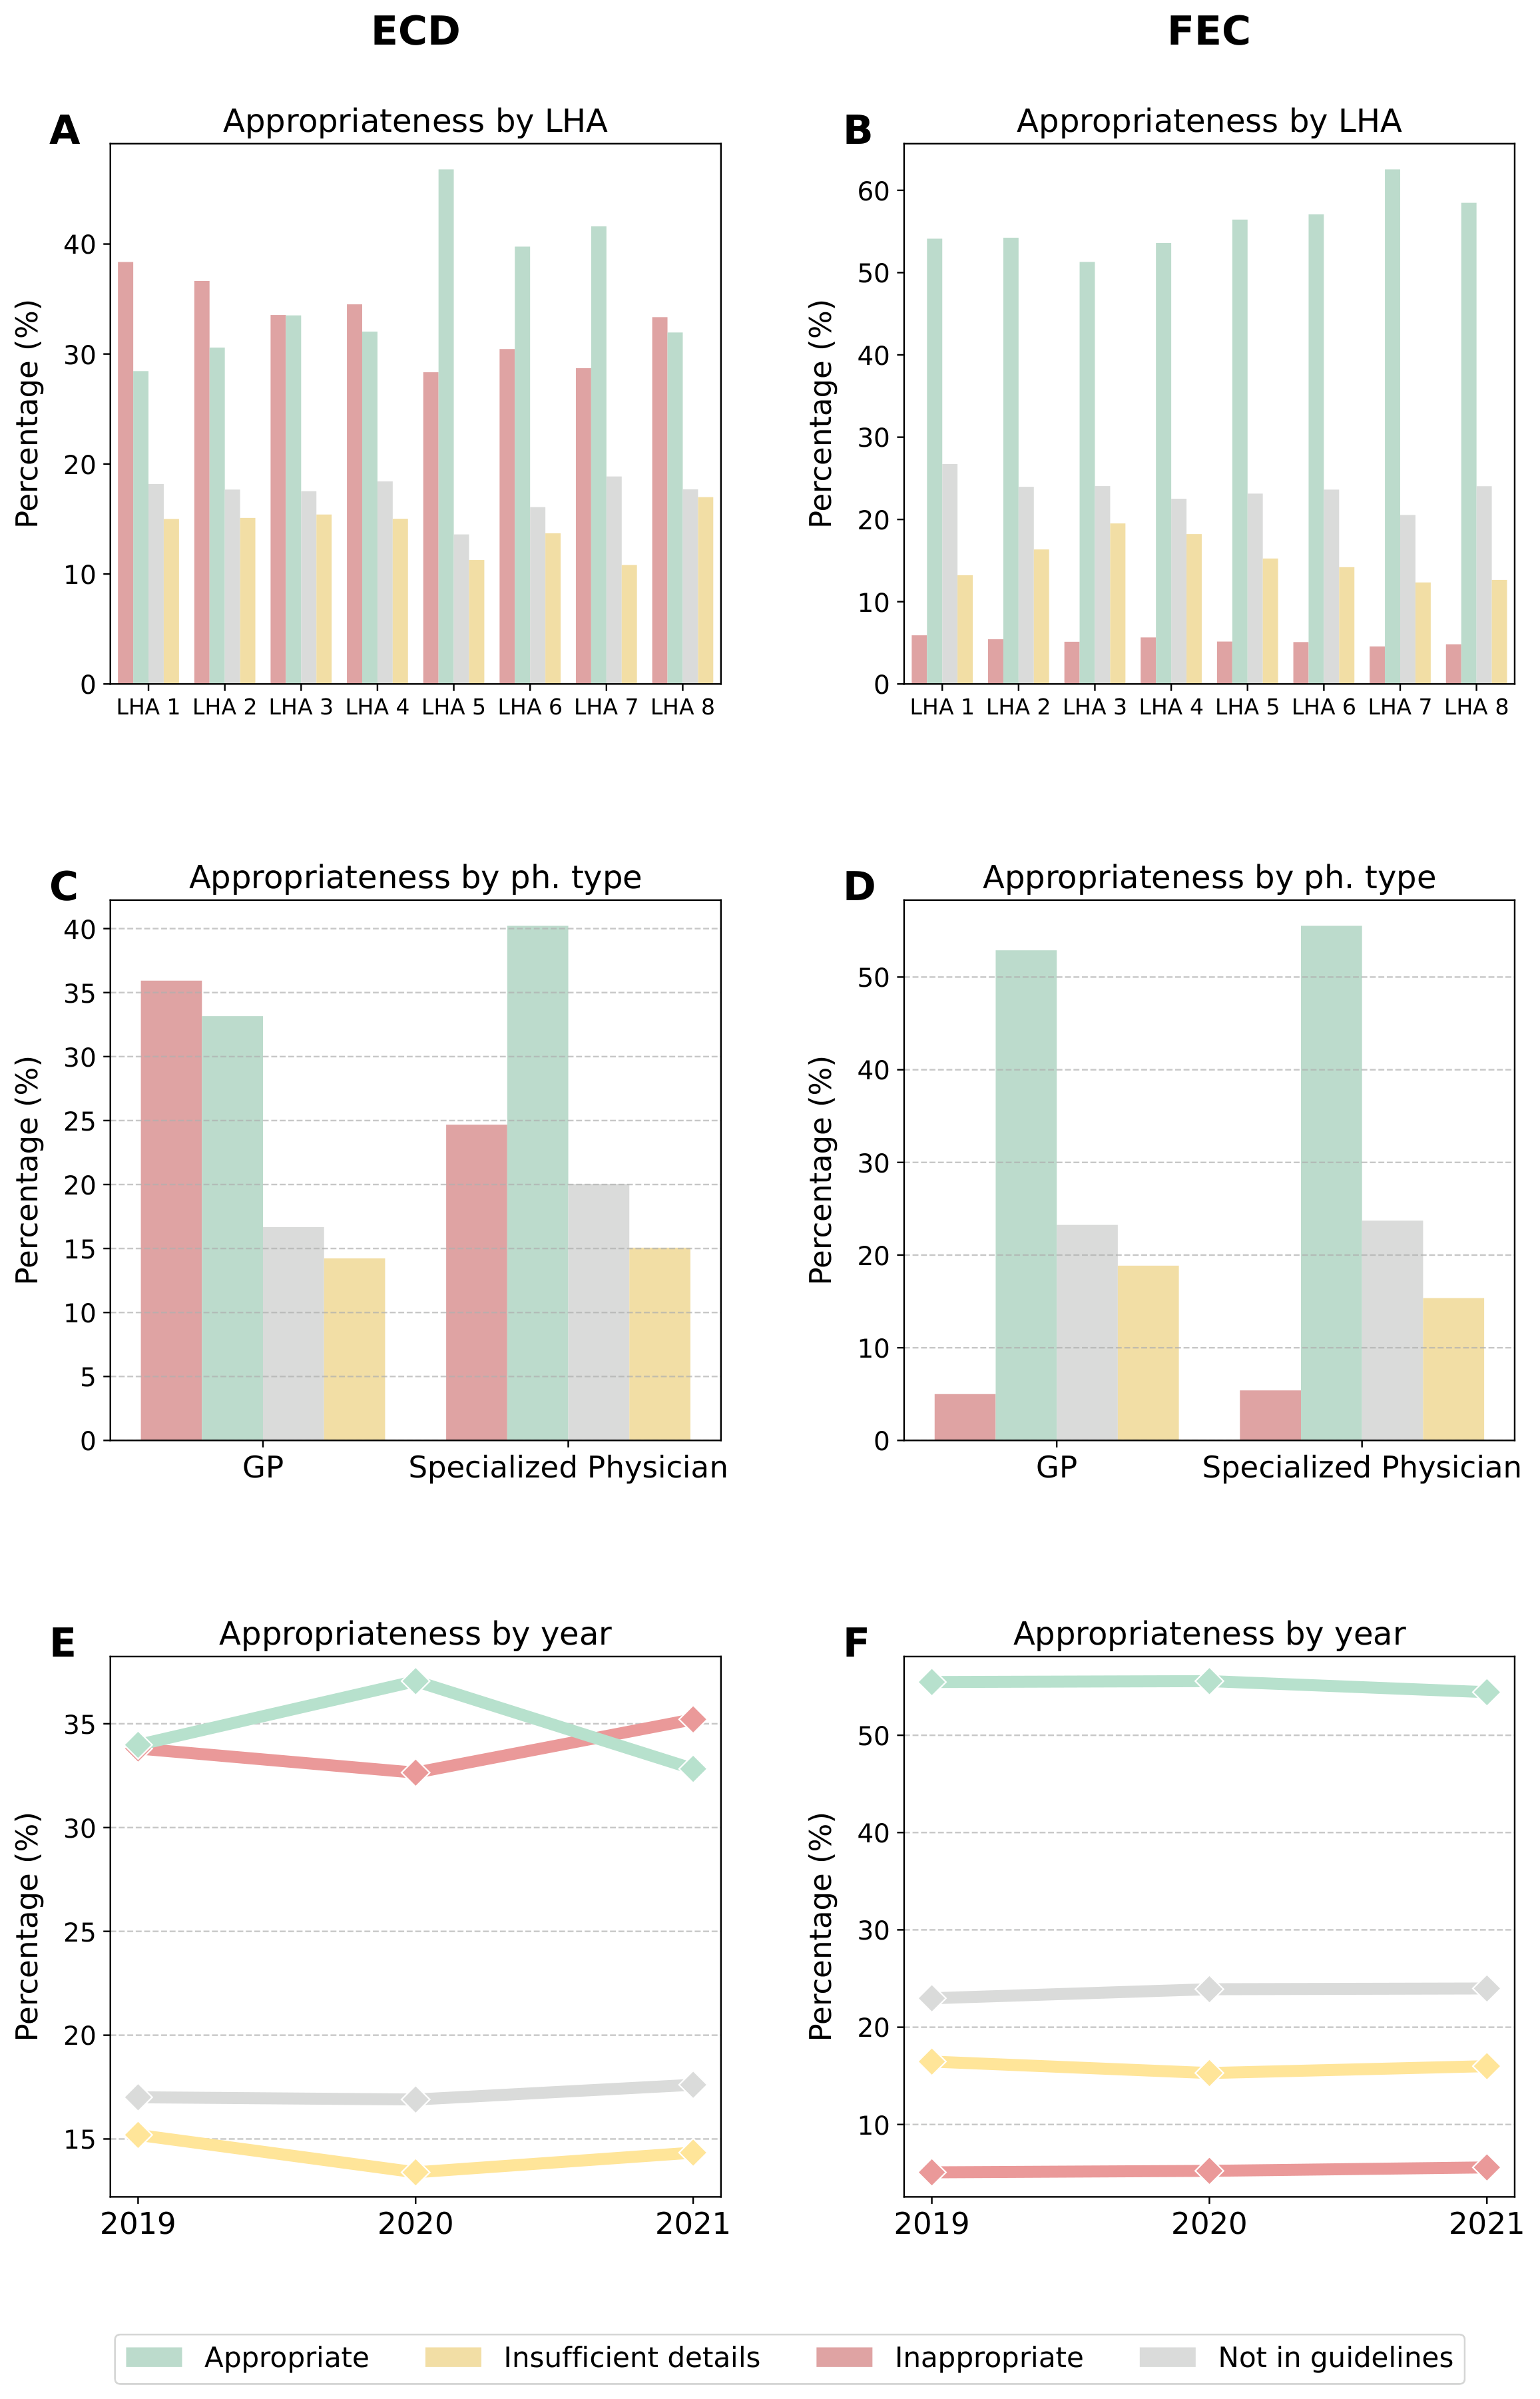

In [51]:
def plot_appropriateness_stratification(exams: dict, savepath: str = None):
    """`exams` maps exam name -> (df_raw, predictions). Reproduces Figure 4: appropriateness by
    LHA, physician type (bars) and year (lines), one column per exam."""
    n_cols = len(exams)
    fig, axs = plt.subplots(3, n_cols, figsize=(6.3 * n_cols, 17.2), gridspec_kw={"wspace": 0.3, "hspace": 0.4})
    if n_cols == 1:
        axs = axs.reshape(3, 1)

    order = ["appropriate", "inappropriate", "likely", "undetermined"]
    palette = [APPROPRIATENESS_COLORS[c] for c in order]

    for col, (exam, (df_raw, predictions)) in enumerate(exams.items()):
        for row, (group_col, kind, title) in enumerate([
            ("LHA", "bar", "Appropriateness by LHA"),
            ("PHYSICIAN_TYPE", "bar", "Appropriateness by ph. type"),
            ("ANNO", "line", "Appropriateness by year"),
        ]):
            ax = axs[row, col]
            data = stratify_appropriateness(df_raw, predictions, group_col)
            if kind == "bar":
                sns.barplot(data=data, x=group_col, y="pct", hue="appropriateness", hue_order=order, palette=palette, ax=ax, errorbar=None)
            else:
                sns.lineplot(data=data, x=group_col, y="pct", hue="appropriateness", hue_order=order, palette=palette, ax=ax, marker="D", linewidth=4)
            ax.set_title(title if col == 0 else "")
            ax.set_xlabel("")
            ax.set_ylabel("Percentage (%)")
            ax.get_legend().remove()
        axs[0, col].annotate(exam, xy=(0.5, 1.15), xycoords="axes fraction", ha="center", fontsize=20, fontweight="bold")

    handles = [plt.Rectangle((0, 0), 1, 1, color=APPROPRIATENESS_COLORS[c]) for c in order]
    fig.legend(handles, [APPROPRIATENESS_DISPLAY[c] for c in order], loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=14)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


plot_appropriateness_stratification({"ECD": (df_ecd, clustered_ecd), "FEC": (df_fec, clustered_fec)}, savepath="appropriateness_by_lha_physician_year.pdf");

## 12. Embedding space visualisation (Supplementary Fig. E.1)

A 2D t-SNE projection of the UmBERTo-E3C embeddings of the manually annotated clinical
questions, coloured by manual label, shows that most disease/symptom categories occupy
distinct regions of the embedding space — visual support for why clustering these embeddings
is an effective proxy for the underlying referral motivation.

In [52]:
from sklearn.manifold import TSNE

try:
    import colorcet as cc
except ImportError as exc:  # pip install colorcet
    raise ImportError("Run `pip install colorcet` for the categorical t-SNE palette.") from exc


def plot_embedding_tsne(annotations: pd.DataFrame, model, tokenizer, title: str, ax, min_label_count: int = 14, perplexity: int = 50, seed: int = 42):
    counts = annotations["LABEL"].value_counts()
    plot_df = annotations[annotations["LABEL"].isin(counts[counts >= min_label_count].index) & (annotations["LABEL"] != "other")].copy()

    embeddings = embed_texts(plot_df["QUESITO_DIAGNOSTICO"].tolist(), model, tokenizer)
    coords = TSNE(n_components=2, random_state=seed, perplexity=perplexity).fit_transform(embeddings)
    coords = coords + np.random.normal(scale=0.5, size=coords.shape)  # jitter overlapping points

    plot_df["label_with_count"] = plot_df["LABEL"].map(lambda label: f"{label} ({counts[label]})")
    palette = cc.glasbey[: plot_df["label_with_count"].nunique()]
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=plot_df["label_with_count"], palette=palette, s=60, ax=ax)
    ax.set_title(title, size=18)
    ax.legend(title="", bbox_to_anchor=(0.5, -0.05), loc="upper center", ncol=3, fontsize=10)
    ax.set_xlabel("TSNE1")
    ax.set_ylabel("TSNE2")

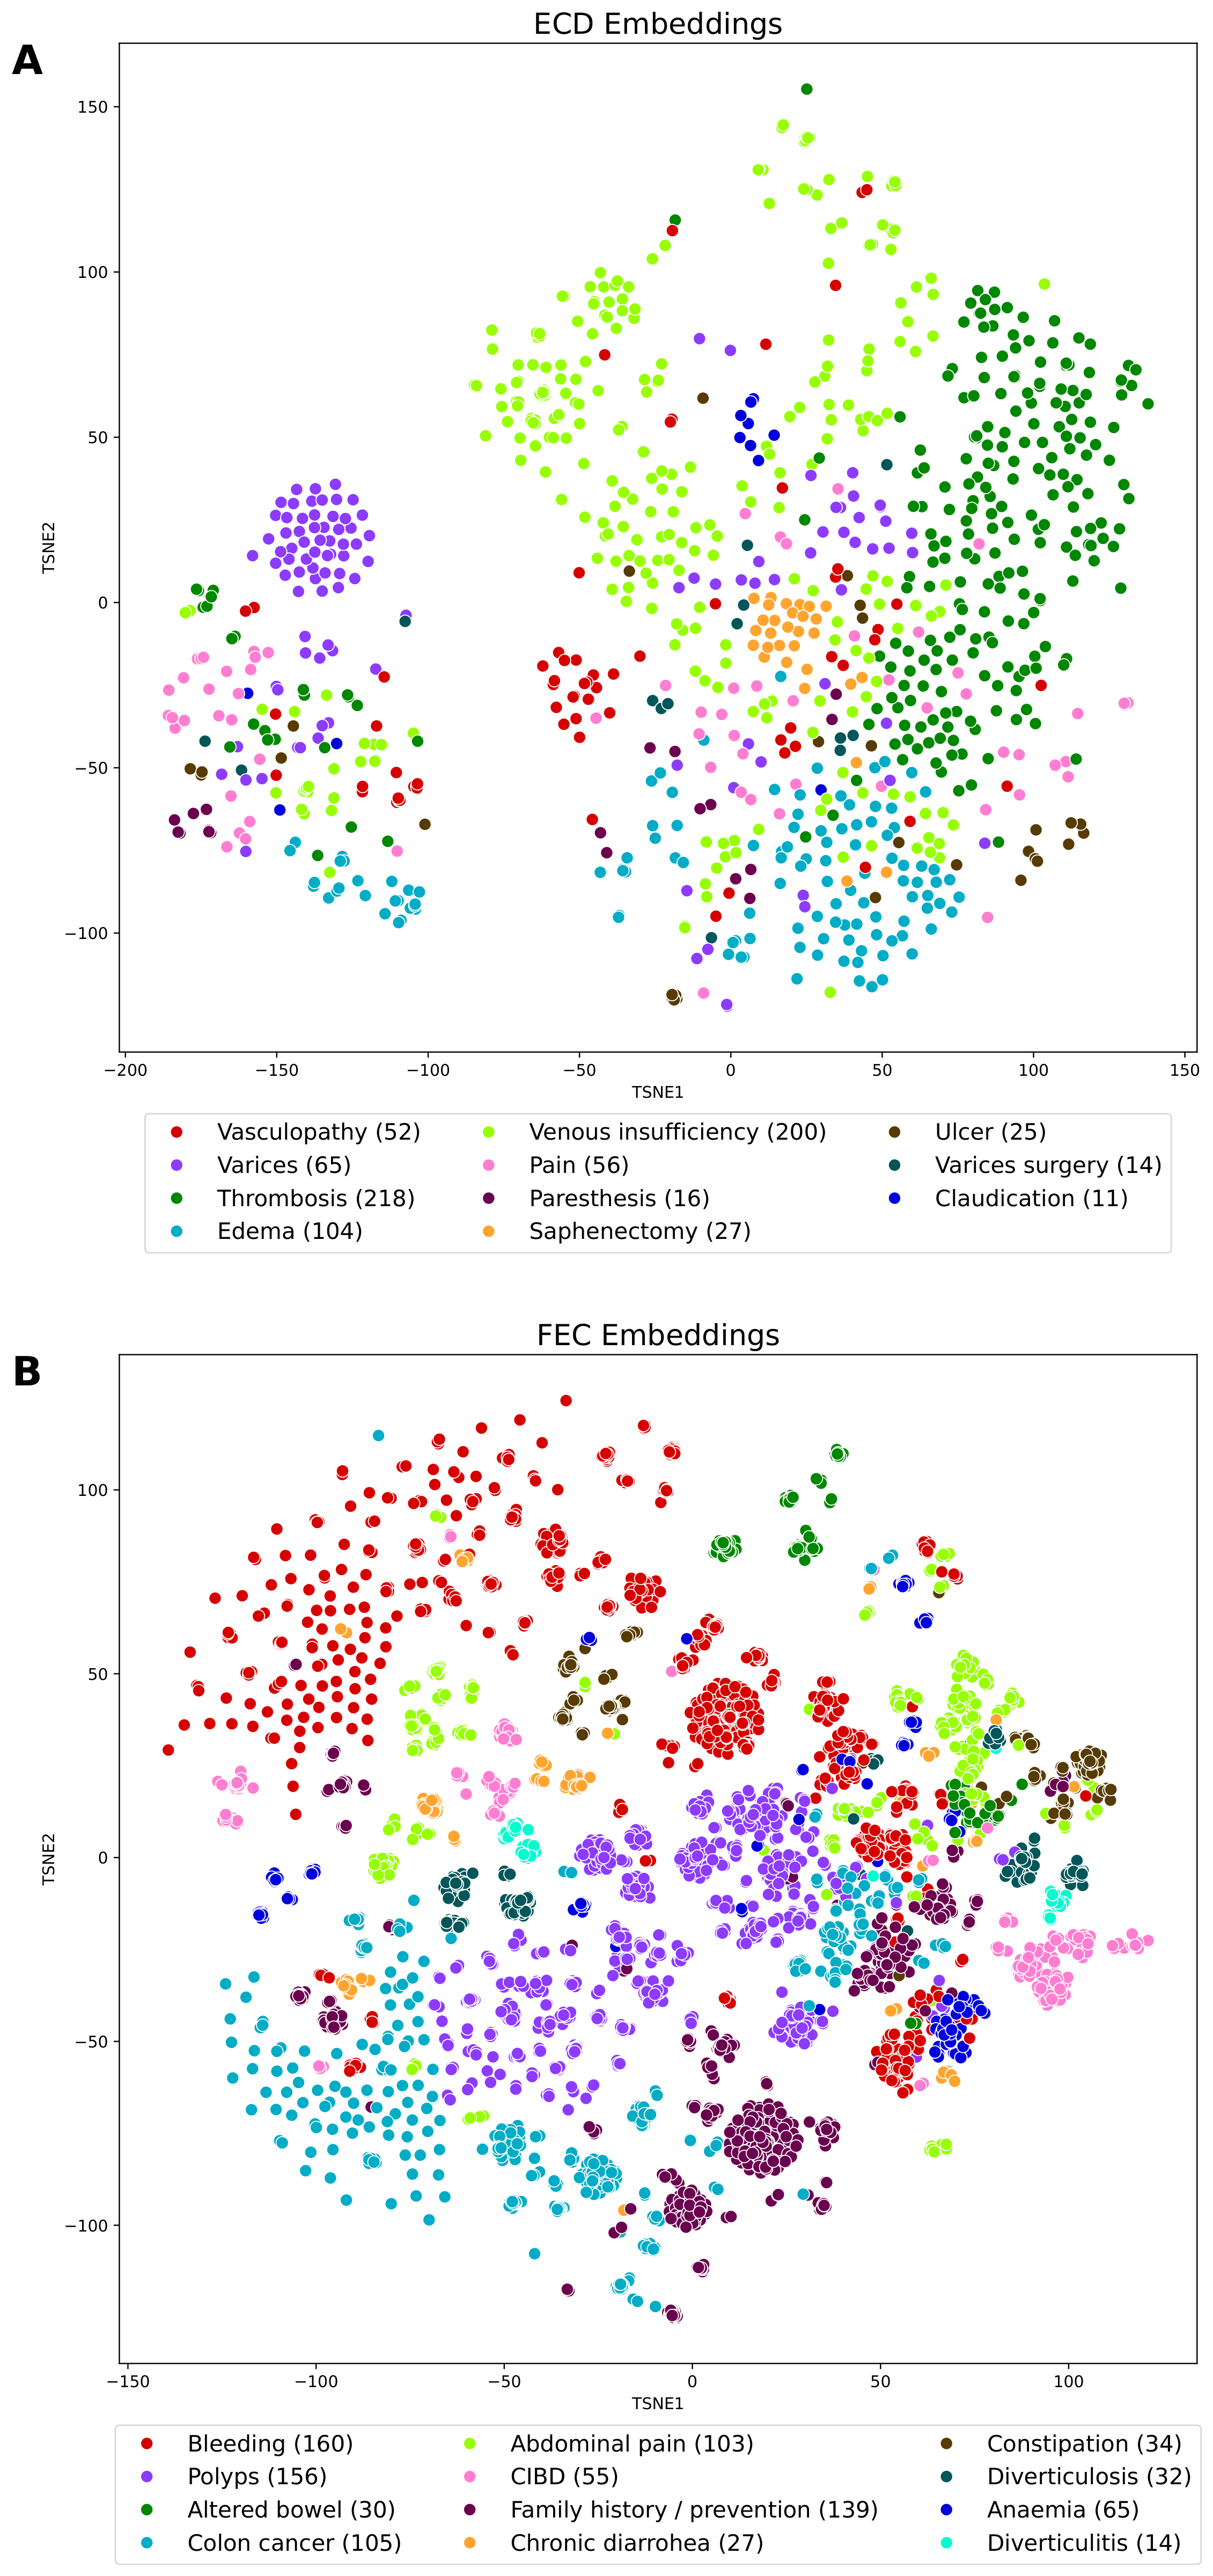

In [53]:
fig, (ax_ecd, ax_fec) = plt.subplots(2, 1, figsize=(12, 22))
plot_embedding_tsne(annotations_ecd, umberto_e3c, umberto_e3c_tokenizer, "ECD Embeddings", ax_ecd)
plot_embedding_tsne(annotations_fec, umberto_e3c, umberto_e3c_tokenizer, "FEC Embeddings", ax_fec)
fig.tight_layout()
fig.savefig("tsne_ecd_fec.pdf", bbox_inches="tight", dpi=300)